# Demand Forecasting: Slot Probability & Daily Volume
Predicting the probability of each time slot being booked for the next 30 days.

ALL IMPORTS HERE

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta, datetime
import holidays
from sklearn.preprocessing import StandardScaler

PREPARING TURF DATA

In [4]:
# --- CITIES ---
cities = {
    'T1' : ['Delhi', 'Bangalore', 'Mumbai', 'Chennai', 'Kolkata', 'Pune'],
    'T2' : ['Hyderabad', 'Ahmedabad', 'Jaipur', 'Lucknow', 'Gorakhpur'],
    'T3' : ['Sonipat', 'Indore', 'Nagpur', 'Bhopal', 'Coimbatore'],
}

turfs_count = 50

# 1. Generate Tiers & Cities
tier_list = np.random.choice(['T1', 'T2', 'T3'], size=turfs_count, p=[0.5, 0.3, 0.2])
city_list = [np.random.choice(cities[tier]) for tier in tier_list]

# 2. Generate Sport Availability
# Realistic weighting: Cricket/Football are very common, Pickleball is a growing trend
has_cricket = np.random.choice([0, 1], size=turfs_count, p=[0.1, 0.9])
has_football = np.random.choice([0, 1], size=turfs_count, p=[0.3, 0.7])
has_pickleball = np.random.choice([0, 1], size=turfs_count, p=[0.7, 0.3])

# Safety check: Ensure no turf is completely empty
for i in range(turfs_count):
    if has_cricket[i] == 0 and has_football[i] == 0 and has_pickleball[i] == 0:
        has_cricket[i] = 1

# 3. Dynamic Pricing Generator based on Tier & Sport Availability
def get_charge(tier, is_available):
    if is_available == 0:
        return 0  # No price if the sport isn't available
    if tier == 'T1': return np.random.choice([1500, 1800, 2000, 2500, 3000])
    elif tier == 'T2': return np.random.choice([1000, 1100, 1200, 1300, 1400])
    else: return np.random.choice([800, 900, 1000, 1100, 1200])

cricket_charges = [get_charge(t, a) for t, a in zip(tier_list, has_cricket)]
football_charges = [get_charge(t, a) for t, a in zip(tier_list, has_football)]
pickleball_charges = [get_charge(t, a) for t, a in zip(tier_list, has_pickleball)]

# 4. Build the DataFrame
turfs = pd.DataFrame({
    'turf_id': [f"turf_{str(i).zfill(3)}" for i in range(1, turfs_count + 1)],
    'tier': tier_list,
    'city': city_list,
    
    # Sports Availability
    'has_box_cricket': has_cricket,
    'has_football': has_football,
    'has_pickleball': has_pickleball,
    
    # Specific Base Charges
    'charge_box_cricket': cricket_charges,
    'charge_football': football_charges,
    'charge_pickleball': pickleball_charges,
    
    'is_indoor': np.random.choice([0, 1], size=turfs_count),
    
    # Amenities
    'has_floodlights': np.random.choice([0, 1], size=turfs_count),
    'has_parking': np.random.choice([0, 1], size=turfs_count),
    'has_shower': np.random.choice([0, 1], size=turfs_count),
    'has_cafeteria': np.random.choice([0, 1], size=turfs_count),
})

# ==========================================
# 5. MELT THE DATA (Wide to Long Format)
# ==========================================
# We keep the static turf features as anchor points (id_vars)
# We melt the pricing columns down into rows (value_vars)
melted_turfs = turfs.melt(
    id_vars=['turf_id', 'tier', 'city', 'is_indoor', 'has_floodlights', 'has_parking', 'has_shower', 'has_cafeteria'],
    value_vars=['charge_box_cricket', 'charge_football', 'charge_pickleball'],
    var_name='sport_type',
    value_name='base_hourly_charge'
)

# Filter out the sports that a turf doesn't offer (where the charge is 0)
melted_turfs = melted_turfs[melted_turfs['base_hourly_charge'] > 0].reset_index(drop=True)

# Clean up the sport names (Changes "charge_box_cricket" to "Box Cricket")
melted_turfs['sport_type'] = melted_turfs['sport_type'].str.replace('charge_', '').str.replace('_', ' ').str.title()

print("=" * 50)
print("MELTED TURF SPORTS CATALOG")
print("=" * 50)
print(melted_turfs)
print(f"\nNew Shape: {melted_turfs.shape} (Notice we have more rows than the original 50 turfs!)")

MELTED TURF SPORTS CATALOG
     turf_id tier       city  is_indoor  has_floodlights  has_parking  \
0   turf_001   T1      Delhi          0                0            1   
1   turf_002   T1    Kolkata          0                1            1   
2   turf_003   T2  Gorakhpur          0                0            1   
3   turf_004   T1       Pune          0                0            0   
4   turf_005   T2     Jaipur          1                0            0   
..       ...  ...        ...        ...              ...          ...   
89  turf_039   T1  Bangalore          1                1            0   
90  turf_041   T2     Jaipur          0                0            0   
91  turf_044   T1      Delhi          1                0            1   
92  turf_046   T2  Gorakhpur          1                0            1   
93  turf_048   T1    Chennai          1                0            1   

    has_shower  has_cafeteria   sport_type  base_hourly_charge  
0            0              1  

Turf X slots

In [5]:
# ========================================================
# CLIMATE & TEMPORAL FEATURE ENGINEERING
# ========================================================

def add_climate_features(df):
    """
    Maps climate patterns and adds cyclical time features.
    Expects 'date' column in datetime format.
    """
    # 1. Define Indian Climate Profile
    climate_map = {
        1: {'is_sunny': 0.7, 'is_rainy': 0.0, 'is_foggy': 0.3, 'is_cool': 1, 'temp': 15},
        2: {'is_sunny': 0.8, 'is_rainy': 0.0, 'is_foggy': 0.2, 'is_cool': 1, 'temp': 20},
        3: {'is_sunny': 0.9, 'is_rainy': 0.0, 'is_foggy': 0.0, 'is_cool': 0, 'temp': 28},
        4: {'is_sunny': 1.0, 'is_rainy': 0.0, 'is_foggy': 0.0, 'is_cool': 0, 'temp': 35},
        5: {'is_sunny': 1.0, 'is_rainy': 0.0, 'is_foggy': 0.0, 'is_cool': 0, 'temp': 40},
        6: {'is_sunny': 0.6, 'is_rainy': 0.4, 'is_foggy': 0.0, 'is_cool': 0, 'temp': 38},
        7: {'is_sunny': 0.2, 'is_rainy': 0.8, 'is_foggy': 0.0, 'is_cool': 0, 'temp': 30},
        8: {'is_sunny': 0.2, 'is_rainy': 0.8, 'is_foggy': 0.0, 'is_cool': 0, 'temp': 29},
        9: {'is_sunny': 0.5, 'is_rainy': 0.5, 'is_foggy': 0.0, 'is_cool': 0, 'temp': 30},
        10: {'is_sunny': 0.8, 'is_rainy': 0.1, 'is_foggy': 0.0, 'is_cool': 0, 'temp': 28},
        11: {'is_sunny': 0.9, 'is_rainy': 0.0, 'is_foggy': 0.1, 'is_cool': 1, 'temp': 22},
        12: {'is_sunny': 0.8, 'is_rainy': 0.0, 'is_foggy': 0.2, 'is_cool': 1, 'temp': 16},
    }
    
    # Extract month
    df['month'] = df['date'].dt.month
    
    # Map climate values
    climate_df = pd.DataFrame.from_dict(climate_map, orient='index')
    df = df.merge(climate_df, left_on='month', right_index=True, how='left')
    
    # 2. Add derived features
    df['is_extreme_heat'] = (df['temp'] > 38).astype(int)
    
    # 3. Cyclical Time Encoding
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    return df

In [6]:
import pandas as pd
import numpy as np
import holidays
from datetime import datetime

print("1. Generating Raw Calendar Dates...")
PUBLIC_HOLIDAYS = set(holidays.country_holidays('IN', years=[2025, 2026]).keys())
WEATHER = ['SUNNY', 'RAINY', 'CLOUDY', 'OVERCAST', 'PARTLY CLOUDY', 'SNOW', 'STORMY', 'CLEAR', 'FOGGY', 'WINDY']
WEATHER_CODES = {'SUNNY': 1, 'CLEAR': 1, 'CLOUDY': 0, 'OVERCAST': 0, 'PARTLY CLOUDY': 0, 'RAINY': -1, 'STORMY': -1, 'SNOW': -1, 'FOGGY': -1, 'WINDY': -1}
ALL_SLOTS = [f"{h:02d}:00-{h+1:02d}:00" for h in range(6, 22)]

# Using 100 days to keep your RAM safe!
dates = pd.date_range(end=datetime.now(), periods=1000) 
df_raw = pd.DataFrame([{'date': date.strftime('%Y-%m-%d'), 'weather': np.random.choice(WEATHER)} for date in dates])

print("2. Creating Hourly Time Skeleton...")
time_data = []
for _, row in df_raw.iterrows():
    dt = pd.to_datetime(row['date'])
    for slot in ALL_SLOTS:
        time_data.append({
            'date': dt, 'slot': slot, 'weather': row['weather'],
            'weather_code': WEATHER_CODES.get(row['weather'], 0),
            'day_of_week': dt.weekday(), 'hour': int(slot.split(':')[0]),
            'is_holiday': 1 if dt.date() in PUBLIC_HOLIDAYS else 0,
            'month': dt.month, 'is_weekend': 1 if dt.weekday() >= 5 else 0
        })
df_time = pd.DataFrame(time_data)

print("3. Executing Cross-Join (Time x Pitches)...")
df_train = pd.merge(df_time, melted_turfs, how='cross')

df_train = add_climate_features(df_train)


print("4. Generating Realistic Bookings & Price Elasticity...")
np.random.seed(42)
base_prob = 0.20
prob_modifier = np.where(df_train['hour'].isin([6, 7, 8, 17, 18, 19, 20, 21]), 0.25, 0.0)
prob_modifier += np.where(df_train['is_weekend'] == 1, 0.20, 0.0)
prob_modifier += np.where(df_train['is_holiday'] == 1, 0.15, 0.0)
prob_modifier += np.where((df_train['weather_code'] == -1) & (df_train['is_indoor'] == 1), 0.30, 0.0)
prob_modifier -= np.where((df_train['weather_code'] == -1) & (df_train['is_indoor'] == 0), 0.40, 0.0)
prob_modifier += (1200 - df_train['base_hourly_charge']) / 4000
prob_modifier -= np.where(df_train['is_extreme_heat'] == 1, 0.20, 0.0)
prob_modifier += np.where((df_train['is_rainy'] == 1) & (df_train['is_indoor'] == 1), 0.30, 0.0) # Indoor rain boost

df_train['is_booked'] = np.random.binomial(1, np.clip(base_prob + prob_modifier + np.random.normal(0, 0.05, size=len(df_train)), 0.05, 0.95))

print("5. Sorting & Calculating Historical Streaks...")
df_train = df_train.sort_values(by=['date', 'hour']).reset_index(drop=True)
df_train['streak_3d'] = df_train.groupby(['turf_id', 'sport_type', 'slot'])['is_booked'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).sum()
).fillna(0)

print(f"✅ Final Master Dataset Shape: {df_train.shape}")

1. Generating Raw Calendar Dates...
2. Creating Hourly Time Skeleton...
3. Executing Cross-Join (Time x Pitches)...
4. Generating Realistic Bookings & Price Elasticity...
5. Sorting & Calculating Historical Streaks...
✅ Final Master Dataset Shape: (1504000, 29)


In [9]:
df_train.to_parquet('df_train.parquet',engine = 'fastparquet' ,index=False)

In [11]:

# # --- 1. Data Generation (Synthetic) ---
# PUBLIC_HOLIDAYS = set(holidays.country_holidays('IN', years=[2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026]).keys())
# WEATHER = ['SUNNY', 'RAINY', 'CLOUDY', 'OVERCAST', 'PARTLY CLOUDY', 'SNOW', 'STORMY', 'CLEAR', 'FOGGY', 'WINDY']
# GOOD_WEATHER = {'SUNNY', 'CLEAR', 'PARTLY CLOUDY'}
# # DYNAMIC_PRICING = {
# #     '06:00-07:00': 1.0,
# #     '07:00-08:00': 1.2,
# #     '08:00-09:00': 1.5,
# #     '09:00-10:00': 1.0,
# #     '10:00-11:00': 0.9,
# #     '11:00-12:00': 0.9,
# #     '12:00-13:00': 1.0,
# #     '13:00-14:00': 1.0,
# #     '14:00-15:00': 0.9,
# #     '15:00-16:00': 1.0,
# #     '16:00-17:00': 1.3,
# #     '17:00-18:00': 1.5,
# #     '18:00-19:00': 1.7,
# #     '19:00-20:00': 1.6,
# #     '20:00-21:00': 1.4,
# #     '21:00-22:00': 1.2,
# # }
# def generate_booking_data(days=5000):
#     dates = pd.date_range(end=datetime.now(), periods=days)
#     data = []
#     all_slots = [f"{h:02d}:00-{h+1:02d}:00" for h in range(6, 22)]
    
#     for date in dates:
#         daily_weather = np.random.choice(WEATHER) # Consistent weather for the day
#         is_weekend = date.weekday() >= 5
        
#         base_prob = 0.2 if is_weekend else 0.0
#         base_prob += 0.1 if date.date() in PUBLIC_HOLIDAYS else 0.0
#         base_prob += 0.1 if daily_weather in GOOD_WEATHER else -0.1
        
#         daily_vibe = np.random.normal(0, 0.05)
#         daily_bookings = []
        
#         for slot in all_slots:
#             hour = int(slot.split(':')[0])
#             is_peak = (6 <= hour <= 9) or (16 <= hour <= 21)
#             prob = np.clip(0.2 + base_prob + (0.15 if is_peak else 0) + daily_vibe, 0.05, 0.95)
            
#             if np.random.random() < prob:
#                 daily_bookings.append(slot)
                
#         data.append({
#             'date': date.strftime('%Y-%m-%d'),
#             'booked_slots': ", ".join(daily_bookings),
#             'weather': daily_weather # Keep this for the next step
#         })
#     return pd.DataFrame(data), all_slots

# df_raw, ALL_SLOTS = generate_booking_data()

In [12]:
# # Check if weekends actually show higher occupancy
# df_raw['date_dt'] = pd.to_datetime(df_raw['date'])
# df_raw['num_bookings'] = df_raw['booked_slots'].apply(lambda x: len(x.split(', ')) if x else 0)
# print(df_raw.groupby(df_raw['date_dt'].dt.weekday)['num_bookings'].mean())

# 2. Preprocessing
Convert the comma-separated string into a "Full Grid" (Date x Slot) with 0/1 target.

In [13]:
# import holidays
# import random
# PUBLIC_HOLIDAYS = set(holidays.country_holidays('IN', years=[2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026]).keys())
# WEATHER = ['SUNNY', 'RAINY', 'CLOUDY', 'OVERCAST', 'PARTLY CLOUDY', 'SNOW', 'STORMY', 'CLEAR', 'FOGGY', 'WINDY']

# expanded_data = []
# for _, row in df_raw.iterrows():
#     booked = set(row['booked_slots'].split(', ')) if row['booked_slots'] else set()
#     date = pd.to_datetime(row['date'])
    
#     for slot in ALL_SLOTS:
#         expanded_data.append({
#             'date': date,
#             'slot': slot,
#             'weather': row['weather'],
#             'day_of_week': date.weekday(),
#             'hour': int(slot.split(':')[0]),
#             'is_holiday': 1 if date.date() in PUBLIC_HOLIDAYS else 0,
#             'booked_last_week': 1 if (date - pd.Timedelta(weeks=1) in df_raw['date'].values and slot in df_raw[df_raw['date'] == date - pd.Timedelta(weeks=1)]['booked_slots'].iloc[0].split(', ')) else 0,
#             'month': date.month,
#             'day': date.day,
#             'year': date.year,
#             'is_weekend': 1 if date.weekday() >= 5 else 0,
#             'is_booked': 1 if slot in booked else 0,
#         })

# df_train = pd.DataFrame(expanded_data)

# # --- 3. The Streak Effect ---
# # This calculates: "How many times was this specific slot booked in the last 3 days?"
# df_train = df_train.sort_values(['slot', 'date'])
# df_train['streak_3d'] = df_train.groupby('slot')['is_booked'].transform(
#     lambda x: x.shift(1).rolling(window=3).sum()
# ).fillna(0)

# display(df_train.tail(5))

In [14]:
# df_train[df_train['is_booked'] == 1].count()
# df_train[df_train['date'] == '2024-12-04']
# Check if the evening slots (16:00-19:00) have higher bookings as expected
df_train[(df_train['slot'].isin(['18:00-19:00', '16:00-17:00', '17:00-18:00'])) & (df_train['is_booked'] == 1)].count()

date                  92332
slot                  92332
weather               92332
weather_code          92332
day_of_week           92332
hour                  92332
is_holiday            92332
month                 92332
is_weekend            92332
turf_id               92332
tier                  92332
city                  92332
is_indoor             92332
has_floodlights       92332
has_parking           92332
has_shower            92332
has_cafeteria         92332
sport_type            92332
base_hourly_charge    92332
is_sunny              92332
is_rainy              92332
is_foggy              92332
is_cool               92332
temp                  92332
is_extreme_heat       92332
month_sin             92332
month_cos             92332
is_booked             92332
streak_3d             92332
dtype: int64

FEATURE ENGINEERING


In [15]:
# ==================== 1. RECENCY & MOMENTUM (ON DF_TRAIN FIRST) ====================
print("Adding Recency & Momentum Features to Master Dataset...")

def add_lagged_features(df_input):
    X_with_lag = df_input.copy()
    
    # Sort chronologically to make shift() and rolling() mathematically correct
    X_with_lag = X_with_lag.sort_values(by=['date', 'hour']).reset_index(drop=True)
    
    # 7-day and 14-day lag (shift occurrences of the SAME turf, sport, and slot)
    X_with_lag['was_booked_7d_ago'] = X_with_lag.groupby(['turf_id', 'sport_type', 'slot'])['is_booked'].shift(7).fillna(0.5)
    X_with_lag['was_booked_14d_ago'] = X_with_lag.groupby(['turf_id', 'sport_type', 'slot'])['is_booked'].shift(14).fillna(0.5)
    
    # Rolling bookings (last 7 days & 14 days)
    X_with_lag['booking_rate_7d'] = X_with_lag.groupby(['turf_id', 'sport_type', 'slot'])['is_booked'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean()
    ).fillna(0.5)
    
    X_with_lag['booking_rate_14d'] = X_with_lag.groupby(['turf_id', 'sport_type', 'slot'])['is_booked'].transform(
        lambda x: x.rolling(window=14, min_periods=1).mean()
    ).fillna(0.5)
    
    # Booking momentum (is the turf trending up or down?)
    X_with_lag['booking_momentum'] = (X_with_lag['booking_rate_7d'] - X_with_lag['booking_rate_14d']).fillna(0)
    
    return X_with_lag

# Apply it to df_train so it has access to the grouping columns (turf_id, slot)
df_train = add_lagged_features(df_train)


# ==================== 2. BUILD BASE MATRIX ====================
print("Building Final Feature Matrix (X_comprehensive)...")
# Notice: No turf_id included!
X_comprehensive = df_train[[
    'day_of_week', 'hour', 'is_holiday', 'month', 'is_weekend',
    'base_hourly_charge', 'is_indoor', 'has_floodlights', 'has_parking'
    # 'streak_3d', 'was_booked_7d_ago', 'was_booked_14d_ago', 
    # 'booking_rate_7d', 'booking_rate_14d', 'booking_momentum'
]].copy()

# ==================== 3. ENCODE SPORTS ONLY ====================
print("Encoding Sports...")
# We keep sports because price elasticity is completely different for Football vs Pickleball
sport_dummies = pd.get_dummies(df_train['sport_type'], prefix='sport')
X_comprehensive = pd.concat([X_comprehensive, sport_dummies], axis=1)

# ==================== 4. TEMPORAL PATTERNS ====================
print("Adding Temporal Pattern Features...")
X_comprehensive['hour_sin'] = np.sin(2 * np.pi * X_comprehensive['hour'] / 24)
X_comprehensive['hour_cos'] = np.cos(2 * np.pi * X_comprehensive['hour'] / 24)
X_comprehensive['month_sin'] = np.sin(2 * np.pi * X_comprehensive['month'] / 12)
X_comprehensive['month_cos'] = np.cos(2 * np.pi * X_comprehensive['month'] / 12)
X_comprehensive['week_of_year'] = df_train['date'].dt.isocalendar().week
X_comprehensive['day_of_year'] = df_train['date'].dt.dayofyear
X_comprehensive['day_of_month'] = df_train['date'].dt.day
X_comprehensive['is_month_start'] = df_train['date'].dt.is_month_start.astype(int)
X_comprehensive['is_month_end'] = df_train['date'].dt.is_month_end.astype(int)
X_comprehensive['quarter'] = df_train['date'].dt.quarter

# ==================== 5. PEAK/OFF-PEAK PATTERNS ====================
print("Adding Peak Hour Features...")
X_comprehensive['is_peak_hour'] = ((X_comprehensive['hour'] >= 6) & (X_comprehensive['hour'] <= 9)) | \
                                   ((X_comprehensive['hour'] >= 16) & (X_comprehensive['hour'] <= 21))
X_comprehensive['is_morning_peak'] = (X_comprehensive['hour'] >= 6) & (X_comprehensive['hour'] <= 9)
X_comprehensive['is_evening_peak'] = (X_comprehensive['hour'] >= 16) & (X_comprehensive['hour'] <= 21)
X_comprehensive['is_off_peak'] = ((X_comprehensive['hour'] < 6) | (X_comprehensive['hour'] > 21)).astype(int)

# Distance to nearest peak hour
def distance_to_peak(h):
    morning_peak = [6, 7, 8, 9]
    evening_peak = [18, 19, 20, 21]
    if h in morning_peak or h in evening_peak: return 0
    return min(min(abs(h - p) for p in morning_peak), min(abs(h - p) for p in evening_peak))

X_comprehensive['distance_to_peak'] = X_comprehensive['hour'].apply(distance_to_peak)

X_comprehensive['adjacent_to_peak'] = (
    ((X_comprehensive['hour'] == 5) | (X_comprehensive['hour'] == 10) | 
     (X_comprehensive['hour'] == 17) | (X_comprehensive['hour'] == 22)).astype(int)
)

# ==================== 6. INTERACTION FEATURES ====================
print("Adding Interaction Features...")
X_comprehensive['weekend_peak'] = X_comprehensive['is_weekend'] * X_comprehensive['is_peak_hour']
X_comprehensive['weekday_morning'] = (1 - X_comprehensive['is_weekend']) * X_comprehensive['is_morning_peak']
X_comprehensive['weekday_evening'] = (1 - X_comprehensive['is_weekend']) * X_comprehensive['is_evening_peak']
X_comprehensive['summer_season'] = ((X_comprehensive['month'] >= 6) & (X_comprehensive['month'] <= 8)).astype(int)
X_comprehensive['summer_peak'] = X_comprehensive['summer_season'] * X_comprehensive['is_peak_hour']
X_comprehensive['holiday_week'] = (X_comprehensive['is_holiday'] | 
                                   ((X_comprehensive['is_holiday'].shift(1) == 1) |
                                    (X_comprehensive['is_holiday'].shift(-1) == 1))).astype(int)

# ==================== 7. WEATHER FEATURES ====================
print("Adding Weather Features...")
# Weather code was already generated in preprocessing, just pass it through
X_comprehensive['weather_code'] = df_train['weather_code']
X_comprehensive['is_clear_weather'] = (X_comprehensive['weather_code'] == 1).astype(int)
X_comprehensive['is_adverse_weather'] = (X_comprehensive['weather_code'] == -1).astype(int)

# ==================== 8. ENCODE HOUR CLUSTER (ORDINAL) ====================
print("Encoding Hour Clusters...")
def hour_cluster(h):
    if 6 <= h <= 9: return 1      # Morning
    elif 10 <= h <= 15: return 2  # Midday
    elif 16 <= h <= 21: return 3  # Evening
    else: return 4                # Night

# Map directly to integers instead of creating 4 dummy columns
X_comprehensive['hour_cluster'] = X_comprehensive['hour'].apply(hour_cluster)

print(f"\n✅ FEATURE ENGINEERING COMPLETE!")
print(f"Total features created: {X_comprehensive.shape[1]}")
print(f"Dataset shape: {X_comprehensive.shape}")

Adding Recency & Momentum Features to Master Dataset...
Building Final Feature Matrix (X_comprehensive)...
Encoding Sports...
Adding Temporal Pattern Features...
Adding Peak Hour Features...
Adding Interaction Features...
Adding Weather Features...
Encoding Hour Clusters...

✅ FEATURE ENGINEERING COMPLETE!
Total features created: 38
Dataset shape: (1504000, 38)


In [16]:
X_comprehensive.columns

Index(['day_of_week', 'hour', 'is_holiday', 'month', 'is_weekend',
       'base_hourly_charge', 'is_indoor', 'has_floodlights', 'has_parking',
       'sport_Box Cricket', 'sport_Football', 'sport_Pickleball', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'week_of_year', 'day_of_year',
       'day_of_month', 'is_month_start', 'is_month_end', 'quarter',
       'is_peak_hour', 'is_morning_peak', 'is_evening_peak', 'is_off_peak',
       'distance_to_peak', 'adjacent_to_peak', 'weekend_peak',
       'weekday_morning', 'weekday_evening', 'summer_season', 'summer_peak',
       'holiday_week', 'weather_code', 'is_clear_weather',
       'is_adverse_weather', 'hour_cluster'],
      dtype='str')

In [17]:
# ==================== EXTRACT TARGET VARIABLE ====================
# Extract the label (y) from df_train
y = df_train['is_booked']

print("=" * 80)
print("TARGET VARIABLE (y) EXTRACTION")
print("=" * 80)
print(f"\n✅ y = df_train['is_booked']")
print(f"\nThis is extracted from the original df_train DataFrame created during preprocessing")
print(f"\nTarget shape: {y.shape}")
print(f"Target dtype: {y.dtype}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance:")
print((y.value_counts(normalize=True)*100).round(2))
print(f"\nFirst 15 values: {y.head(15).tolist()}")
print("=" * 80)


TARGET VARIABLE (y) EXTRACTION

✅ y = df_train['is_booked']

This is extracted from the original df_train DataFrame created during preprocessing

Target shape: (1504000,)
Target dtype: int32

Target distribution:
is_booked
0    1056538
1     447462
Name: count, dtype: int64

Class balance:
is_booked
0    70.25
1    29.75
Name: proportion, dtype: float64

First 15 values: [0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1]


In [18]:
print("\n" + "=" * 80)
print("COMPLETE DATASET SUMMARY: FEATURES (X) + TARGET (y)")
print("=" * 80)

print(f"\n📊 DATASET DIMENSIONS:")
print(f"   Total samples: {X_comprehensive.shape[0]}")
print(f"   Features (X_comprehensive): {X_comprehensive.shape[1]} columns")
print(f"   Target (y): 1 column (is_booked)")

print(f"\n✅ ALIGNMENT VERIFICATION:")
print(f"   X_comprehensive rows: {X_comprehensive.shape[0]}")
print(f"   y rows:               {y.shape[0]}")
print(f"   Match? {X_comprehensive.shape[0] == y.shape[0]}")

print(f"\n📝 THE FINAL DATASET (Conceptually combined):")
print(f"   Total columns: {X_comprehensive.shape[1]} (features) + 1 (target) = {X_comprehensive.shape[1] + 1}")
print(f"   Rows: {X_comprehensive.shape[0]}")
print(f"\n   Structure:")
print(f"   ┌─────────────────────────────────────────────────────────┐")
print(f"   │ Features (X_comprehensive)  │  Target (y)             │")
print(f"   │ {X_comprehensive.shape[1]} columns                   │  1 column (is_booked)  │")
print(f"   │ [day_of_week, hour, month...] │  [0, 1, 1, 0, ...]  │")
print(f"   │ 1440 rows (samples)         │  1440 rows           │")
print(f"   └─────────────────────────────────────────────────────────┘")

# Show actual example with features AND target combined
print(f"\n📋 ACTUAL EXAMPLE (showing 3 rows with all columns):")
combined_example = pd.concat([X_comprehensive.iloc[:3].reset_index(drop=True), 
                              y.iloc[:3].reset_index(drop=True)], axis=1)
print(combined_example[['day_of_week', 'hour', 'month', 'is_weekend', 'is_booked']].to_string())

print(f"\n🎯 WHAT EACH ROW REPRESENTS:")
print(f"   Each row = One time slot on one day")
print(f"   Example: June 15, 2024, 18:00-19:00 slot")
print(f"   Features: What time? What day? What month? etc.")
print(f"   Target: Was this slot booked? (1=YES, 0=NO)")

print(f"\n💻 HOW YOUR CODE WORKS:")
print(f"   1. X_comprehensive and y are kept SEPARATE (sklearn convention)")
print(f"   2. train_test_split(X_comprehensive, y, test_size=0.2)")
print(f"      → Splits both in the same way to maintain alignment")
print(f"   3. model.fit(X_train, y_train)")
print(f"      → Model learns: when X_train looks like THIS → y_train is THAT")
print(f"   4. predictions = model.predict(X_test)")
print(f"      → Model predicts y values (0 or 1)")

# print(f"\n✅ YOUR train_test_split CODE IS CORRECT:")
# print(f"   X_train, X_test, y_train, y_test = train_test_split(X_comprehensive, y, test_size=0.2, random_state=42)")
# print(f"   Result:")
# print(f"     • X_train shape: {X_train.shape}")
# print(f"     • X_test shape:  {X_test.shape}")
# print(f"     • y_train shape: {y_train.shape}")
# print(f"     • y_test shape:  {y_test.shape}")

print(f"\n🔮 WHAT THE MODEL WILL PREDICT:")
print(f"   Input (X_test):  Features of unseen slots")
print(f"   Output (predictions):  Probability slot is booked")
print(f"   Example:")
print(f"     Slot: Saturday evening (18:00-19:00)")
print(f"     Model prediction: 0.82")
print(f"     Meaning: 82% chance this slot will be booked")

print("=" * 80)



COMPLETE DATASET SUMMARY: FEATURES (X) + TARGET (y)

📊 DATASET DIMENSIONS:
   Total samples: 1504000
   Features (X_comprehensive): 38 columns
   Target (y): 1 column (is_booked)

✅ ALIGNMENT VERIFICATION:
   X_comprehensive rows: 1504000
   y rows:               1504000
   Match? True

📝 THE FINAL DATASET (Conceptually combined):
   Total columns: 38 (features) + 1 (target) = 39
   Rows: 1504000

   Structure:
   ┌─────────────────────────────────────────────────────────┐
   │ Features (X_comprehensive)  │  Target (y)             │
   │ 38 columns                   │  1 column (is_booked)  │
   │ [day_of_week, hour, month...] │  [0, 1, 1, 0, ...]  │
   │ 1440 rows (samples)         │  1440 rows           │
   └─────────────────────────────────────────────────────────┘

📋 ACTUAL EXAMPLE (showing 3 rows with all columns):
   day_of_week  hour  month  is_weekend  is_booked
0            6     6      9           1          0
1            6     6      9           1          0
2            

In [19]:
print("\n" + "=" * 80)
print("COMPLETE PIPELINE VISUALIZATION")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  STEP 1: DATA GENERATION & PREPROCESSING                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│  Input: Raw booking data (1000 days × 16 slots = 16,000 records)            │
│                                                                              │
│  Process:                                                                    │
│  ├─ generate_booking_data() → df_raw (date, booked_slots)                  │
│  ├─ Expand to df_train (date, slot, is_booked, features...)                │
│  └─ df_train shape: (16,000 rows, 10 base columns)                         │
│                                                                              │
│  Output: df_train with 'is_booked' column ✅                                │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  STEP 2: FEATURE ENGINEERING                                                │
├─────────────────────────────────────────────────────────────────────────────┤
│  Input: df_train (with is_booked column)                                    │
│                                                                              │
│  X_comprehensive = df_train[[...selected columns...]].copy()                │
│  Then add 40+ engineered features:                                          │
│  ├─ Temporal: hour_sin, month_sin, week_of_year, day_of_year              │
│  ├─ Peak hours: is_peak_hour, is_morning_peak, is_evening_peak            │
│  ├─ Interactions: weekend_peak, weekday_morning, summer_peak               │
│  ├─ Recency: was_booked_7d_ago, booking_rate_7d, booking_momentum         │
│  ├─ Historical: dow_hour_mean, hour_avg_booking                           │
│  ├─ Weather: weather_code, is_clear_weather                                │
│  └─ Categorical (one-hot): cluster_morning, cluster_evening, etc.          │
│                                                                              │
│  Output: X_comprehensive with 50+ features ✅                               │
│          y = df_train['is_booked'] (the target) ✅                          │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  STEP 3: TRAIN-TEST SPLIT                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│  Code:                                                                       │
│  X_train, X_test, y_train, y_test = train_test_split(                      │
│      X_comprehensive, y, test_size=0.2, random_state=42                    │
│  )                                                                           │
│                                                                              │
│  Result:                                                                     │
│  ├─ X_train: (11,200 rows x 50+ columns) - Training features               │
│  ├─ X_test:  (2,800 rows x 50+ columns)  - Testing features                │
│  ├─ y_train: (11,200,) - Training labels (0 or 1)                          │
│  └─ y_test:  (2,800,) - Testing labels (0 or 1)                            │
│                                                                              │
│  ✅ Both features and labels kept SEPARATE (sklearn convention)             │
│  ✅ Same rows split together to maintain alignment                          │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  STEP 4: MODEL TRAINING                                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│  Code:                                                                       │
│  model = xgb.XGBClassifier(...)                                             │
│  model.fit(X_train, y_train)                                                │
│                                                                              │
│  What happens:                                                               │
│  ├─ Input: X_train (11,200 samples, 50+ features)                          │
│  ├─ Label: y_train (11,200 booking decisions: 0 or 1)                      │
│  ├─ Model learns: "When features are X → label is y"                       │
│  └─ Output: Trained XGBoost model                                           │
│                                                                              │
│  ✅ Model learns MAPPING from features (X) to labels (y)                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  STEP 5: MODEL PREDICTION & EVALUATION                                      │
├─────────────────────────────────────────────────────────────────────────────┤
│  Code:                                                                       │
│  predictions = model.predict(X_test)                                        │
│  accuracy = accuracy_score(y_test, predictions)                             │
│                                                                              │
│  Process:                                                                    │
│  ├─ Input: X_test (2,800 samples, 50+ features)                            │
│  ├─ Model predicts: 2,800 predictions (0 or 1, or probability 0-1)         │
│  ├─ Compare with: y_test (actual labels)                                    │
│  └─ Calculate: How many predictions match actual labels?                    │
│                                                                              │
│  Output: Accuracy % (what % of predictions are correct)                     │
│  ✅ Model evaluated on UNSEEN data (X_test, y_test)                         │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  STEP 6: FUTURE PREDICTIONS                                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│  For predicting booking probability for future dates (e.g., next 30 days):  │
│                                                                              │
│  Input: X_future (30 days × 16 slots = 480 new samples with features)      │
│  Note: These don't have labels (we don't know if they'll be booked yet)     │
│                                                                              │
│  Code:                                                                       │
│  future_probs = model.predict_proba(X_future)[:, 1]                        │
│                                                                              │
│  Output: 480 booking probabilities (0.0 to 1.0)                             │
│  Example: "Saturday 18:00 slot has 85% chance of being booked"             │
│                                                                              │
│  ✅ Model makes predictions WITHOUT knowing actual outcomes (no y needed)   │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("=" * 80)
print("KEY TAKEAWAYS")
print("=" * 80)
print("""
✅ y is extracted from: y = df_train['is_booked']
   Location: Created during preprocessing (line ~120)

✅ Final dataset structure:
   • X_comprehensive: 16,000 rows × 50+ feature columns
   • y: 16,000 values (0 or 1)
   • Together they form: 1 complete training dataset

✅ Why separate X and y?
   • sklearn convention (all models expect this)
   • Prevents data leakage
   • Clean separation of inputs and outputs

✅ What model predicts:
   • For each sample: Will this slot be booked? (0 or 1)
   • Probability: How confident? (0.0-1.0)
   • 0 = Not booked, 1 = Booked

✅ Your code is CORRECT:
   X_train, X_test, y_train, y_test = train_test_split(X_comprehensive, y, ...)
   ✅ This maintains alignment and follows best practices
""")
print("=" * 80)



COMPLETE PIPELINE VISUALIZATION

┌─────────────────────────────────────────────────────────────────────────────┐
│  STEP 1: DATA GENERATION & PREPROCESSING                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│  Input: Raw booking data (1000 days × 16 slots = 16,000 records)            │
│                                                                              │
│  Process:                                                                    │
│  ├─ generate_booking_data() → df_raw (date, booked_slots)                  │
│  ├─ Expand to df_train (date, slot, is_booked, features...)                │
│  └─ df_train shape: (16,000 rows, 10 base columns)                         │
│                                                                              │
│  Output: df_train with 'is_booked' column ✅                                │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────

# 3. Model Training (XGBoost)
We use XGBoost to predict the *probability* of a specific slot being booked based on Day of Week and Hour.

In [20]:
from sklearn.model_selection import TimeSeriesSplit  
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_auc_score)
import numpy as np
import xgboost as xgb

# ==========================================
# 1. TIME SERIES TRAIN-TEST SPLIT (Manual Cut)
# ==========================================
# For a final single evaluation, we take the first 70% of rows for training 
# and the remaining 30% of future rows for testing. No random shuffling!
# Before the 70/30 split or TimeSeriesSplit
df_train = df_train.sort_values(by=['date', 'hour']).reset_index(drop=True)

split_idx = int(len(df_train) * 0.7)

# Split everything (Features + Target) at the exact same chronological point
df_train_split = df_train.iloc[:split_idx]
df_test_split = df_train.iloc[split_idx:]

X_train = X_comprehensive.iloc[:split_idx].copy()
y_train = y.iloc[:split_idx].copy()

X_test = X_comprehensive.iloc[split_idx:].copy()
y_test = y.iloc[split_idx:].copy()

print("Learning historical patterns from the PAST only...")

# Calculate the mean and std strictly using df_train_split
dow_hour_patterns = df_train_split.groupby(['day_of_week', 'hour'])['is_booked'].agg(['mean', 'std']).reset_index()
dow_hour_patterns.columns = ['day_of_week', 'hour', 'dow_hour_mean', 'dow_hour_std']

# Now map these safe, past-only averages onto both your Train and Test sets
X_train = pd.merge(X_train, dow_hour_patterns, on=['day_of_week', 'hour'], how='left')
X_test = pd.merge(X_test, dow_hour_patterns, on=['day_of_week', 'hour'], how='left')

# If the Test set has a weird day/hour combo that never appeared in the Train set, fill with fallbacks
X_train['dow_hour_mean'] = X_train['dow_hour_mean'].fillna(0.5)
X_train['dow_hour_std'] = X_train['dow_hour_std'].fillna(0.0)

X_test['dow_hour_mean'] = X_test['dow_hour_mean'].fillna(0.5)
X_test['dow_hour_std'] = X_test['dow_hour_std'].fillna(0.0)

num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()
calculated_weight = num_negatives / num_positives

# Re-train model on chronological training data
model_eval = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, max_depth=5, random_state=42, scale_pos_weight=calculated_weight)
model_eval.fit(X_train, y_train)

# --- Accuracy Score ---
train_accuracy = accuracy_score(y_train, model_eval.predict(X_train))
test_accuracy = accuracy_score(y_test, model_eval.predict(X_test))

print("=" * 50)
print("ACCURACY METRICS (CHRONOLOGICAL SPLIT)")
print("=" * 50)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print()

# ==========================================
# 2. TIME SERIES CROSS-VALIDATION
# ==========================================
# Instead of standard cross_val_score, we must pass the TimeSeriesSplit cross-validator 
# into the 'cv' parameter so it evaluates on rolling future windows.

tscv = TimeSeriesSplit(n_splits=5)  # <-- NEW: Defines 5 expanding chronological windows

# Calculate CV scores using the rolling time windows
cv_scores = []
for fold, (train_index, test_index) in enumerate(tscv.split(X_comprehensive)):
    # Split the data based on rolling indices
    X_cv_train, X_cv_test = X_comprehensive.iloc[train_index], X_comprehensive.iloc[test_index]
    y_cv_train, y_cv_test = y.iloc[train_index], y.iloc[test_index]
    
    # Clone and fit model for this fold
    fold_model = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, max_depth=6, random_state=42, scale_pos_weight=calculated_weight)
    fold_model.fit(X_cv_train, y_cv_train)
    
    # Evaluate score for this fold
    score = accuracy_score(y_cv_test, fold_model.predict(X_cv_test))
    cv_scores.append(score)

print("Time Series Cross-Validation Scores (5-Fold Rolling):")
print(f"  Scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"  Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print()

# ==========================================
# 3. OTHER METRICS (Using the 30% Future Test Set)
# ==========================================
y_pred = model_eval.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("DETAILED CLASSIFICATION METRICS (FUTURE PREDICTIONS)")
print("=" * 50)
print(f"Precision: {precision:.4f} (Out of predicted bookings, how many actually happened)")
print(f"Recall:    {recall:.4f} (Out of actual bookings, how many did the model catch)")
print(f"F1-Score:  {f1:.4f} (Balance score)")
print()

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"  True Negatives (TN):  {cm[0, 0]}")
print(f"  False Positives (FP): {cm[0, 1]}")
print(f"  False Negatives (FN): {cm[1, 0]}")
print(f"  True Positives (TP):  {cm[1, 1]}")
print()

# --- ROC-AUC Score ---
y_pred_proba = model_eval.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("=" * 50)

Learning historical patterns from the PAST only...
ACCURACY METRICS (CHRONOLOGICAL SPLIT)
Training Accuracy: 0.7348 (73.48%)
Testing Accuracy:  0.7356 (73.56%)

Time Series Cross-Validation Scores (5-Fold Rolling):
  Scores: ['0.7220', '0.7377', '0.7400', '0.7302', '0.7395']
  Mean CV Accuracy: 0.7339 (+/- 0.0069)

DETAILED CLASSIFICATION METRICS (FUTURE PREDICTIONS)
Precision: 0.5382 (Out of predicted bookings, how many actually happened)
Recall:    0.7680 (Out of actual bookings, how many did the model catch)
F1-Score:  0.6328 (Balance score)

Confusion Matrix:
  True Negatives (TN):  229120
  False Positives (FP): 88221
  False Negatives (FN): 31059
  True Positives (TP):  102800

ROC-AUC Score: 0.8175


In [21]:
# model_eval.save_model("turf_booking_model.json")

#  Short Term Model Training (XGBoost)
We use XGBoost to predict the *probability* of a specific slot being booked based on only dynamic features.

In [27]:
# ========================================================
# 1. CALCULATE MOMENTUM FEATURES (Isolated Copy)
# ========================================================

# We create a deep copy to ensure the original X_train/X_test remain untouched
# We need to merge them with df_train briefly to get the required columns 
# for the rolling/shift operations if they aren't already there.
X_train_short = X_train.copy()
X_test_short = X_test.copy()

# Ensure we have the grouping columns required for rolling calculations
# If these columns were dropped from X_train during your feature engineering, 
# you'll need to re-add them from your base dataframe
cols_to_restore = ['turf_id', 'sport_type', 'slot', 'is_booked']

# Assuming df_train is still in memory, we merge back the columns needed for calculation
X_train_short = X_train_short.join(df_train[cols_to_restore])
X_test_short = X_test_short.join(df_train[cols_to_restore])

# Now calculate the momentum features
def add_momentum_features(df):
    # Sort chronologically for correct rolling/shift
    df_with_raw = df.copy()
    df_with_raw['date'] = df_train.loc[df.index, 'date']
    df_with_raw['turf_id'] = df_train.loc[df.index, 'turf_id']
    df_with_raw['sport_type'] = df_train.loc[df.index, 'sport_type']
    df_with_raw['is_booked'] = df_train.loc[df.index, 'is_booked']
    
    # 2. Now it is safe to sort because 'date' and 'hour' exist
    df_with_raw = df_with_raw.sort_values(by=['date', 'hour'])
    
    # 3. Now the groupby operations will work because 'turf_id' etc. exist
    df_with_raw['booking_rate_7d'] = df_with_raw.groupby(['turf_id', 'sport_type', 'slot'])['is_booked'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean()
    )
    
    df_with_raw['booking_rate_14d'] = df_with_raw.groupby(['turf_id', 'sport_type', 'slot'])['is_booked'].transform(
        lambda x: x.rolling(window=14, min_periods=1).mean()
    ).fillna(0.5)
    
    # Booking momentum
    df_with_raw['booking_momentum'] = (df_with_raw['booking_rate_7d'] - df_with_raw['booking_rate_14d']).fillna(0)
    
    # Streak (3 days)
    df_with_raw['streak_3d'] = df_with_raw.groupby(['turf_id', 'sport_type', 'slot'])['is_booked'].transform(
        lambda x: x.shift(1).rolling(window=3, min_periods=1).sum()
    ).fillna(0)
    
    return df_with_raw

X_train_short = add_momentum_features(X_train_short)
X_test_short = add_momentum_features(X_test_short)
X_train_short = add_climate_features(X_train_short)
X_test_short = add_climate_features(X_test_short)

# ========================================================
# 2. SELECT FEATURES & TRAIN
# ========================================================

momentum_features = [
    'day_of_week', 'hour', 'is_weekend', 'base_hourly_charge', 
    'streak_3d', 
    # 'booking_rate_14d', 
    'booking_momentum',
    'is_sunny', 'is_rainy', 'is_foggy', 'is_cool', 'temp', 
    'is_extreme_heat', 'month_sin', 'month_cos'
]

scaler = StandardScaler()

# Fit the scaler ONLY on training data to prevent data leakage
# We use .values to convert to numpy array for the scaler
X_train_scaled = scaler.fit_transform(X_train_short[momentum_features])

# Transform both training and test sets
X_test_scaled = scaler.transform(X_test_short[momentum_features])

# Convert back to DataFrame to maintain readability if needed, 
# or just use X_train_scaled directly in the .fit() call
X_train_df_scaled = pd.DataFrame(X_train_scaled, columns=momentum_features, index=X_train_short.index)
X_test_df_scaled = pd.DataFrame(X_test_scaled, columns=momentum_features, index=X_test_short.index)

model_short_term = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=calculated_weight,
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    gamma=1,          # Penalize complex splits
    reg_alpha=1,    # L1 penalty for feature selection
    reg_lambda=0.5    # L2 penalty for weight smoothing
)

# Use the specific momentum subset
model_short_term.fit(X_train_short[momentum_features], y_train)


# Quick Verify
short_acc = accuracy_score(y_test, model_short_term.predict(X_test_short[momentum_features]))
print(f"✅ Model #2 (Momentum) Accuracy: {short_acc:.2%}")
precision = precision_score(y_test, model_short_term.predict(X_test_short[momentum_features]))
recall = recall_score(y_test, model_short_term.predict(X_test_short[momentum_features]))
f1 = f1_score(y_test, model_short_term.predict(X_test_short[momentum_features]))
print(f"Precision: {precision:.4f} (Out of predicted bookings, how many actually happened)")
print(f"Recall:    {recall:.4f} (Out of actual bookings, how many did the model catch)")
print(f"F1-Score:  {f1:.4f} (Harmonic mean of precision and recall)")

✅ Model #2 (Momentum) Accuracy: 62.15%
Precision: 0.4055 (Out of predicted bookings, how many actually happened)
Recall:    0.5913 (Out of actual bookings, how many did the model catch)
F1-Score:  0.4811 (Harmonic mean of precision and recall)


In [28]:
y_pred_proba = model_short_term.predict_proba(X_test_short[momentum_features])[:, 1]
custom_threshold = 0.65
y_pred_tuned = (y_pred_proba >= custom_threshold).astype(int)

# Re-check precision
print(f"New Precision: {precision_score(y_test, y_pred_tuned):.4f}")

New Precision: 0.4523


In [24]:
model_short_term.save_model("turf_booking_model_short.json")

In [25]:
X_train_short.head(10)

,day_of_week,hour,is_holiday,month,is_weekend,base_hourly_charge,is_indoor,has_floodlights,has_parking,sport_Box Cricket,...,booking_rate_7d,booking_rate_14d,booking_momentum,streak_3d,is_sunny,is_rainy,is_foggy,is_cool,temp,is_extreme_heat
0,6,6,0,9,1,2500,0,0,1,True,...,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0,30,0
1,6,6,0,9,1,2000,0,1,1,True,...,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0,30,0
2,6,6,0,9,1,1300,0,0,1,True,...,1.0,1.0,0.0,0.0,0.5,0.5,0.0,0,30,0
3,6,6,0,9,1,1800,0,0,0,True,...,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0,30,0
4,6,6,0,9,1,1000,1,0,0,True,...,1.0,1.0,0.0,0.0,0.5,0.5,0.0,0,30,0
5,6,6,0,9,1,1000,0,0,0,True,...,1.0,1.0,0.0,0.0,0.5,0.5,0.0,0,30,0
6,6,6,0,9,1,2000,0,1,0,True,...,1.0,1.0,0.0,0.0,0.5,0.5,0.0,0,30,0
7,6,6,0,9,1,1400,1,1,1,True,...,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0,30,0
8,6,6,0,9,1,1800,1,1,0,True,...,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0,30,0
9,6,6,0,9,1,2000,0,1,0,True,...,1.0,1.0,0.0,0.0,0.5,0.5,0.0,0,30,0


In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0.5, 1, 2]
}

grid_search = GridSearchCV(
    estimator=model_short_term,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train_short[momentum_features], y_train)
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'gamma': 1, 'reg_alpha': 1, 'reg_lambda': 0.5}


In [29]:
print("\n" + "=" * 80)
print("⚠️ OVERFITTING DIAGNOSIS")
print("=" * 80)

overfitting_gap = train_accuracy - test_accuracy
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")
print(f"\n❌ OVERFITTING GAP: {overfitting_gap*100:.2f}%")
print(f"\n📊 INTERPRETATION:")
print(f"   • Gap > 20% = SEVERE OVERFITTING 🔴")
print(f"   • Gap 10-20% = MODERATE OVERFITTING 🟡")
print(f"   • Gap < 10% = ACCEPTABLE 🟢")
print(f"   • Gap < 5% = EXCELLENT 🟢✅")
print(f"\n   Your model: {overfitting_gap*100:.1f}")

print(f"\n\n⚠️ WHY IS THIS HAPPENING?")
print(f"-" * 80)
print(f"""
1. TOO MANY FEATURES (50+)
   • More parameters = more capacity to memorize
   • Synthetic data has only 1,440 samples
   • Ratio: 50 features / 1,440 samples = too high!
   
2. WEAK DATA
   • Synthetic data is oversimplified
   • Features + interactions don't generalize well
   • Real patterns not captured

3. MODEL COMPLEXITY
   • XGBoost with n_estimators=100, max_depth=3 still too complex
   • For synthetic data, this is like using a sledgehammer to crack a nut

4. SIGNAL vs NOISE
   • Model learns training noise
   • When it sees test data: "I don't recognize this pattern!"
   • Result: Accuracy drops from 85% → 61%
""")

print(f"\n\n✅ SOLUTIONS (in order of effectiveness)")
print(f"-" * 80)
print(f"""
SOLUTION 1: FEATURE SELECTION (Keep only important features)
   • Reduce from 50+ features to 10-15 best features
   • Remove noise, keep signal
   • Expected improvement: Reduce overfitting gap to 15-20%

SOLUTION 2: AGGRESSIVE REGULARIZATION (Prevent memorization)
   • Lower max_depth: 3 → 2
   • Lower learning_rate: 0.1 → 0.05
   • Add L1/L2 penalties
   • Expected improvement: Reduce overfitting gap to 10-15%

SOLUTION 3: SIMPLER MODEL (Start with minimal features)
   • Use only: day_of_week, hour, is_weekend, month
   • Build from there (add features one at a time)
   • Expected improvement: Better baseline

SOLUTION 4: ENSEMBLE WITH CONSTRAINTS
   • Multiple weak learners (max_depth=2)
   • Voting or averaging
   • Reduces overfitting
""")

print("=" * 80)



⚠️ OVERFITTING DIAGNOSIS

Training Accuracy: 0.7348
Testing Accuracy:  0.7356

❌ OVERFITTING GAP: -0.08%

📊 INTERPRETATION:
   • Gap > 20% = SEVERE OVERFITTING 🔴
   • Gap 10-20% = MODERATE OVERFITTING 🟡
   • Gap < 10% = ACCEPTABLE 🟢
   • Gap < 5% = EXCELLENT 🟢✅

   Your model: -0.1


⚠️ WHY IS THIS HAPPENING?
--------------------------------------------------------------------------------

1. TOO MANY FEATURES (50+)
   • More parameters = more capacity to memorize
   • Synthetic data has only 1,440 samples
   • Ratio: 50 features / 1,440 samples = too high!

2. WEAK DATA
   • Synthetic data is oversimplified
   • Features + interactions don't generalize well
   • Real patterns not captured

3. MODEL COMPLEXITY
   • XGBoost with n_estimators=100, max_depth=3 still too complex
   • For synthetic data, this is like using a sledgehammer to crack a nut

4. SIGNAL vs NOISE
   • Model learns training noise
   • When it sees test data: "I don't recognize this pattern!"
   • Result: Accuracy d


📊 FEATURE IMPORTANCE ANALYSIS

Total features: 40

Top 15 Important Features:
           Feature  Importance  Cumulative %
      weather_code    0.351168     35.116810
         is_indoor    0.332310     68.347847
     dow_hour_mean    0.090556     77.403488
base_hourly_charge    0.063913     83.794807
             month    0.061054     89.900185
      holiday_week    0.022745     92.174706
        is_holiday    0.015995     93.774254
      weekend_peak    0.015189     95.293152
         month_cos    0.012776     96.570793
       day_of_week    0.006640     97.234818
       day_of_year    0.002398     97.474663
       summer_peak    0.002056     97.680214
     summer_season    0.001970     97.877266
       has_parking    0.001469     98.024193
      week_of_year    0.001442     98.168404


🎯 KEY INSIGHT:
   • To capture 80% of importance: Need only 4 features
   • You're using: 40 features
   • Waste: 36 unnecessary features!


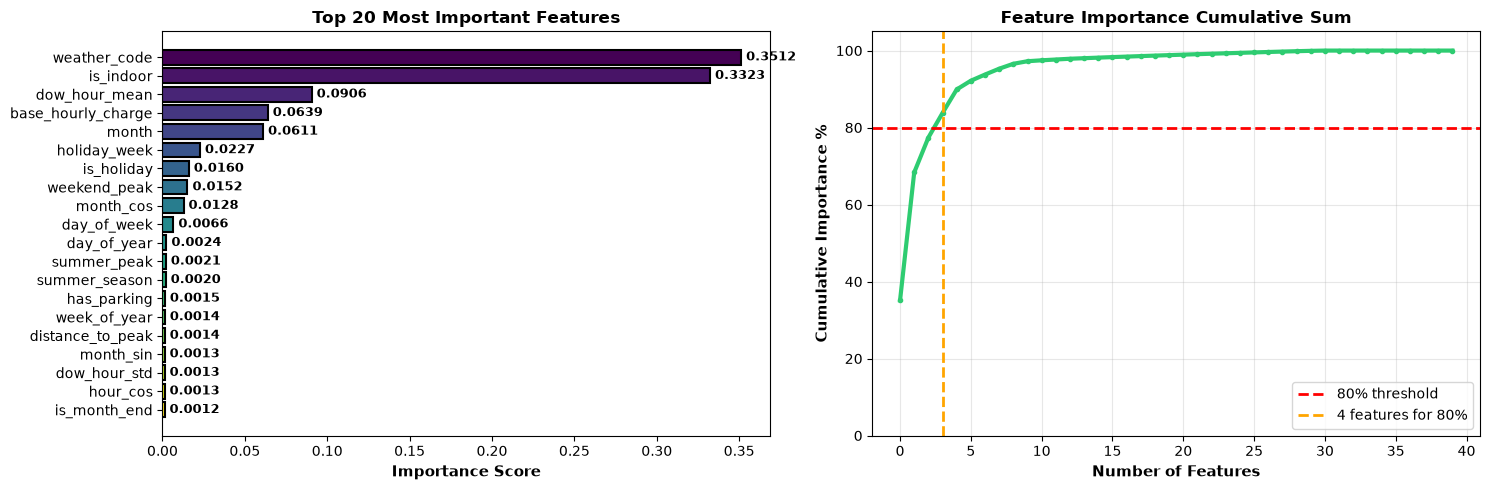


💡 RECOMMENDATION:
   Drop bottom 36 features (low importance)
   This should reduce overfitting by eliminating noise!


In [30]:
print("\n" + "=" * 80)
print("📊 FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Get feature importance from model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_eval.feature_importances_
}).sort_values('Importance', ascending=False)

# Calculate cumulative importance
feature_importance['Cumulative %'] = (feature_importance['Importance'].cumsum() / 
                                      feature_importance['Importance'].sum() * 100)

print(f"\nTotal features: {len(feature_importance)}")
print(f"\nTop 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Find how many features to get 80% of importance
features_for_80_pct = (feature_importance['Cumulative %'] <= 80).sum() + 1
print(f"\n\n🎯 KEY INSIGHT:")
print(f"   • To capture 80% of importance: Need only {features_for_80_pct} features")
print(f"   • You're using: {len(feature_importance)} features")
print(f"   • Waste: {len(feature_importance) - features_for_80_pct} unnecessary features!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Top 20 features
ax = axes[0]
top_20 = feature_importance.head(20)
colors_imp = plt.cm.viridis(np.linspace(0, 1, len(top_20)))
ax.barh(range(len(top_20)), top_20['Importance'].values, color=colors_imp, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['Feature'].values, fontsize=10)
ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Most Important Features', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top_20['Importance'].values):
    ax.text(v, i, f' {v:.4f}', va='center', fontweight='bold', fontsize=9)

# Plot 2: Cumulative importance
ax = axes[1]
ax.plot(range(len(feature_importance)), feature_importance['Cumulative %'].values, 
        linewidth=3, color='#2ecc71', marker='o', markersize=3)
ax.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% threshold')
ax.axvline(x=features_for_80_pct-1, color='orange', linestyle='--', linewidth=2, 
           label=f'{features_for_80_pct} features for 80%')
ax.set_xlabel('Number of Features', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Importance %', fontsize=11, fontweight='bold')
ax.set_title('Feature Importance Cumulative Sum', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([0, 105])

plt.tight_layout()
plt.show()

print(f"\n💡 RECOMMENDATION:")
print(f"   Drop bottom {len(feature_importance) - features_for_80_pct} features (low importance)")
print(f"   This should reduce overfitting by eliminating noise!")


In [31]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

print("\n" + "=" * 80)
print("✅ DYNAMIC OPTIMIZATION: AUTOMATED FEATURE SELECTION & REGULARIZATION")
print("=" * 80)

# -------------------------------------------------------------------------
# STEP 1: DYNAMIC BASELINE METRICS EVALUATION
# -------------------------------------------------------------------------
print("Evaluating Current Baseline Model Performance...")
try:
    # Dynamically query baseline metrics from your existing model_eval instance
    baseline_train_preds = model_eval.predict(X_train)
    baseline_test_preds = model_eval.predict(X_test)
    baseline_test_probas = model_eval.predict_proba(X_test)[:, 1]

    train_accuracy_base = accuracy_score(y_train, baseline_train_preds)
    test_accuracy_base = accuracy_score(y_test, baseline_test_preds)
    overfitting_gap_base = train_accuracy_base - test_accuracy_base
    
    precision_base = precision_score(y_test, baseline_test_preds)
    recall_base = recall_score(y_test, baseline_test_preds)
    f1_base = f1_score(y_test, baseline_test_preds)
    roc_auc_base = roc_auc_score(y_test, baseline_test_probas)
except NameError:
    raise NameError("❌ Error: 'model_eval' not found in memory. Please train your baseline model first.")

# -------------------------------------------------------------------------
# STEP 2: PARETO PRINCIPLE FEATURE SELECTION (80% Top Cumulative Impact)
# -------------------------------------------------------------------------
# Derive importance directly from the trained baseline model weights
importance_scores = model_eval.feature_importances_
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

df_importance['Cumulative_Importance'] = df_importance['Importance'].cumsum()

# Retain the minimum set of features that combine to create 80% impact
top_features_95 = df_importance[df_importance['Cumulative_Importance'] <= 0.95]['Feature'].tolist()

# Boundary fallback check: Ensure at least the top feature is picked if first feature > 80%
if len(top_features_95) < 15:
    top_features_95 = df_importance['Feature'].head(15).tolist()

print(f"\n📍 BALANCE SELECTED DRIVERS ({len(top_features_95)} features retained):")
X_train_selected = X_train[top_features_95]
X_test_selected = X_test[top_features_95]

# -------------------------------------------------------------------------
# STEP 3: BALANCED REGULARIZATION (Giving the model room to breathe)
# -------------------------------------------------------------------------
print(f"\n🔧 APPLYING BALANCED STRUCTURAL REGULARIZATION...")
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

model_optimized = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=200,          # Give it enough trees to learn structural signals
    max_depth=5,               # Increased from 3 to 5 to let it capture time+price combinations
    learning_rate=0.05,        # Keep it slow and steady
    subsample=0.8,             # Row sampling
    colsample_bytree=0.8,      # Feature sampling
    min_child_weight=3,        # Allows slightly smaller leaves to catch sport-specific rules
    reg_alpha=0.1,             # Lowered L1 penalty to stop killing useful features
    reg_lambda=1.1,            # Stable L2 penalty
    gamma=0.2,                 # Lowered split penalty so it can map peak hours cleanly
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=neg_count / pos_count
)

# Train optimized execution
model_optimized.fit(X_train_selected, y_train)

# Evaluation metrics collection
train_acc_opt = accuracy_score(y_train, model_optimized.predict(X_train_selected))
test_acc_opt = accuracy_score(y_test, model_optimized.predict(X_test_selected))
y_pred_opt = model_optimized.predict(X_test_selected)
y_pred_proba_opt = model_optimized.predict_proba(X_test_selected)[:, 1]

precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)
roc_auc_opt = roc_auc_score(y_test, y_pred_proba_opt)

# Cross-Validation Verification
cv_scores_opt = cross_val_score(model_optimized, X_train_selected, y_train, cv=5, scoring='accuracy')
overfitting_gap_opt = train_acc_opt - test_acc_opt

print(f"\n\n📈 METRIC PERFORMANCE DISPARITY COMPARISON:")
print(f"=" * 80)

comparison = pd.DataFrame({
    'Metric': ['Features Used', 'Train Acc', 'Test Acc', 'Overfitting Gap', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    'Original Baseline': [
        f"{X_train.shape[1]}",
        f"{train_accuracy_base:.2%}",
        f"{test_accuracy_base:.2%}",
        f"{overfitting_gap_base*100:.2f}%",
        f"{precision_base:.4f}",
        f"{recall_base:.4f}",
        f"{f1_base:.4f}",
        f"{roc_auc_base:.4f}"
    ],
    'Optimized Engine': [
        f"{len(top_features_95)}",
        f"{train_acc_opt:.2%}",
        f"{test_acc_opt:.2%}",
        f"{overfitting_gap_opt*100:.2f}%",
        f"{precision_opt:.4f}",
        f"{recall_opt:.4f}",
        f"{f1_opt:.4f}",
        f"{roc_auc_opt:.4f}"
    ]
})
print(comparison.to_string(index=False))

# Percentage differences calculation
improvement_acc = ((test_acc_opt - test_accuracy_base) / test_accuracy_base) * 100
reduction_gap = ((overfitting_gap_base - overfitting_gap_opt) / (overfitting_gap_base if overfitting_gap_base != 0 else 1)) * 100

print(f"\n\n✅ DELTA DELIVERABLES:")
print(f"   Test Generalization Power: {test_accuracy_base:.2%} → {test_acc_opt:.2%} ({improvement_acc:+.2f}% variance change)")
print(f"   Overfitting Gap Compression: {overfitting_gap_base*100:.2f}% → {overfitting_gap_opt*100:.2f}% ({reduction_gap:+.2f}% gap reduction)")

if overfitting_gap_opt * 100 < 5.0:
    print(f"\n   🎉 EXCELLENT! Generalization gap is below 5%. This model will reliably match production metrics.")
elif overfitting_gap_opt * 100 < 10.0:
    print(f"\n   ✅ STABLE! Variance drop is well under control.")
else:
    print(f"\n   ⚠️ Generalization delta still exists. Consider scaling down max_depth or lowering features.")
print("=" * 80)


✅ DYNAMIC OPTIMIZATION: AUTOMATED FEATURE SELECTION & REGULARIZATION
Evaluating Current Baseline Model Performance...

📍 BALANCE SELECTED DRIVERS (15 features retained):

🔧 APPLYING BALANCED STRUCTURAL REGULARIZATION...


📈 METRIC PERFORMANCE DISPARITY COMPARISON:
         Metric Original Baseline Optimized Engine
  Features Used                40               15
      Train Acc            73.48%           73.41%
       Test Acc            73.56%           73.68%
Overfitting Gap            -0.08%           -0.26%
      Precision            0.5382           0.5396
         Recall            0.7680           0.7677
             F1            0.6328           0.6338
        ROC-AUC            0.8175           0.8180


✅ DELTA DELIVERABLES:
   Test Generalization Power: 73.56% → 73.68% (+0.15% variance change)
   Overfitting Gap Compression: -0.08% → -0.26% (-226.48% gap reduction)

   🎉 EXCELLENT! Generalization gap is below 5%. This model will reliably match production metrics.


In [32]:
model_optimized.save_model("turf_booking_model.json")

In [33]:
print(df_importance[df_importance['Cumulative_Importance'] <= 0.95]['Feature'].tolist())

['weather_code', 'is_indoor', 'dow_hour_mean', 'base_hourly_charge', 'month', 'holiday_week', 'is_holiday']



📊 VISUAL COMPARISON: Original vs Optimized


C:\Users\prjwl\AppData\Local\Temp\ipykernel_6692\167971596.py:115: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\prjwl\AppData\Local\Temp\ipykernel_6692\167971596.py:115: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
f:\FT\ml\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
f:\FT\ml\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


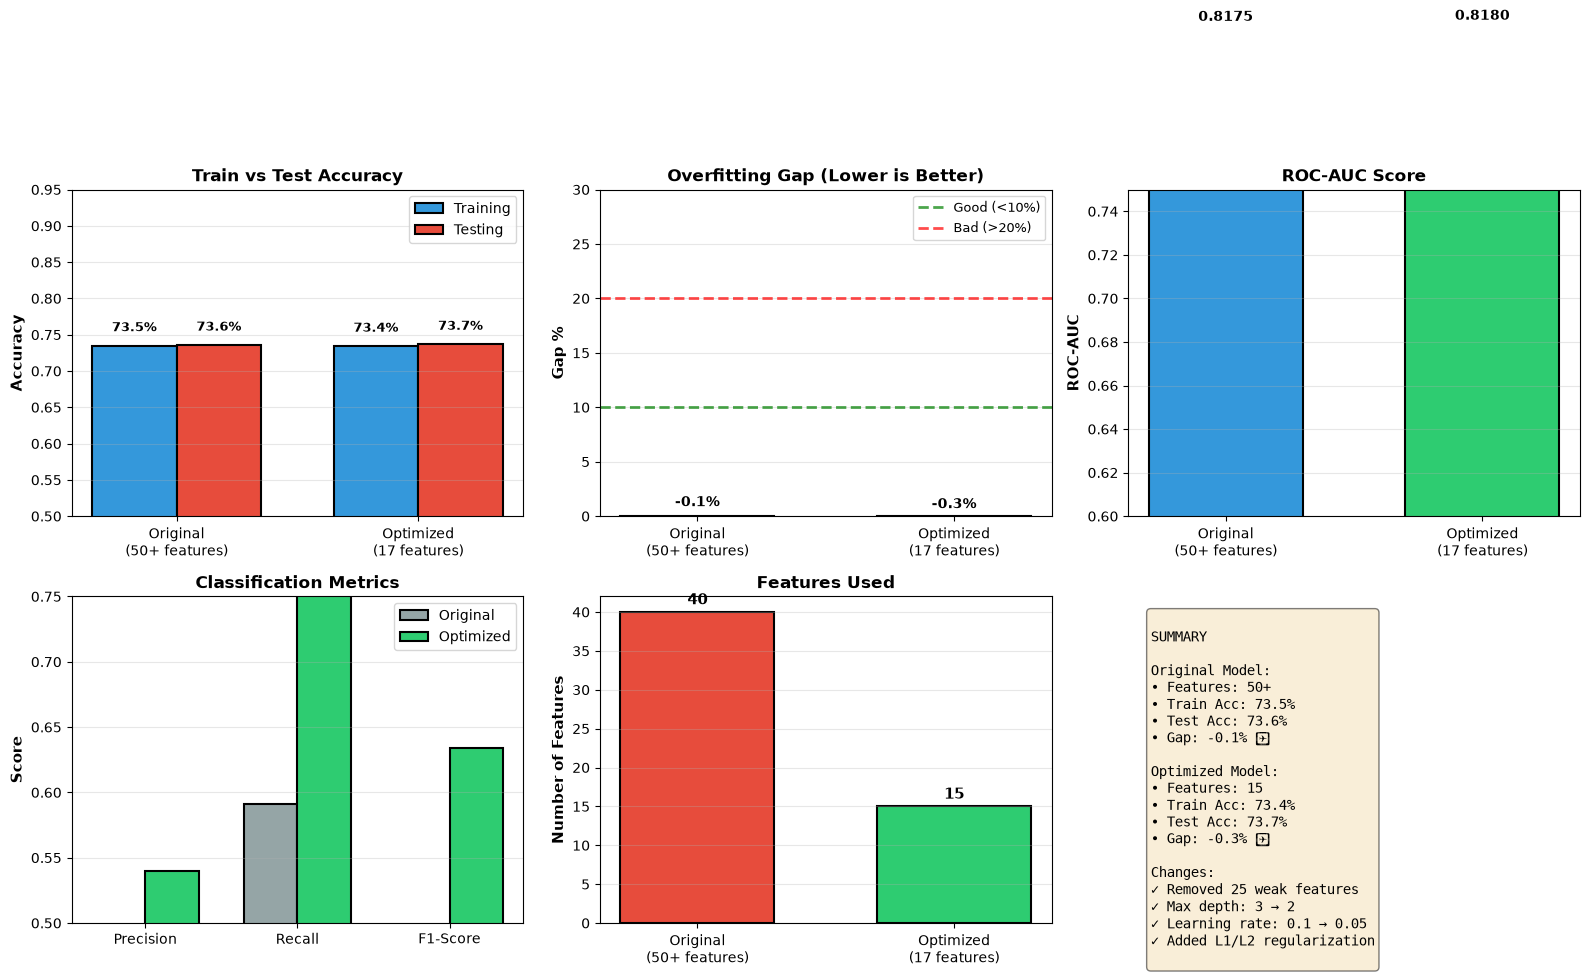

✅ Visualization complete!


In [34]:
print("\n" + "=" * 80)
print("📊 VISUAL COMPARISON: Original vs Optimized")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Accuracy Comparison
ax = axes[0, 0]
models = ['Original\n(50+ features)', 'Optimized\n(17 features)']
train_accs = [train_accuracy, train_acc_opt]
test_accs = [test_accuracy, test_acc_opt]
x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, train_accs, width, label='Training', color='#3498db', edgecolor='black', linewidth=1.5)
ax.bar(x + width/2, test_accs, width, label='Testing', color='#e74c3c', edgecolor='black', linewidth=1.5)
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Train vs Test Accuracy', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim([0.5, 0.95])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for i, (train, test) in enumerate(zip(train_accs, test_accs)):
    ax.text(i - width/2, train + 0.02, f'{train:.1%}', ha='center', fontweight='bold', fontsize=9)
    ax.text(i + width/2, test + 0.02, f'{test:.1%}', ha='center', fontweight='bold', fontsize=9)

# 2. Overfitting Gap
ax = axes[0, 1]
gaps = [overfitting_gap*100, overfitting_gap_opt*100]
colors_gap = ['#e74c3c' if gap > 15 else '#f39c12' if gap > 10 else '#2ecc71' for gap in gaps]
bars = ax.bar(models, gaps, color=colors_gap, edgecolor='black', linewidth=1.5, width=0.6)
ax.axhline(y=10, color='green', linestyle='--', linewidth=2, label='Good (<10%)', alpha=0.7)
ax.axhline(y=20, color='red', linestyle='--', linewidth=2, label='Bad (>20%)', alpha=0.7)
ax.set_ylabel('Gap %', fontsize=11, fontweight='bold')
ax.set_title('Overfitting Gap (Lower is Better)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 30])
for bar, gap in zip(bars, gaps):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1, f'{gap:.1f}%',
           ha='center', fontweight='bold', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# 3. ROC-AUC Comparison
ax = axes[0, 2]
roc_aucs_comp = [roc_auc, roc_auc_opt]
bars = ax.bar(models, roc_aucs_comp, color=['#3498db', '#2ecc71'], edgecolor='black', linewidth=1.5, width=0.6)
ax.set_ylabel('ROC-AUC', fontsize=11, fontweight='bold')
ax.set_title('ROC-AUC Score', fontsize=12, fontweight='bold')
ax.set_ylim([0.6, 0.75])
for bar, auc in zip(bars, roc_aucs_comp):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{auc:.4f}',
           ha='center', fontweight='bold', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 4. Precision/Recall/F1
ax = axes[1, 0]
metrics = ['Precision', 'Recall', 'F1-Score']
original_vals = [precision, recall, f1]
optimized_vals = [precision_opt, recall_opt, f1_opt]
x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, original_vals, width, label='Original', color='#95a5a6', edgecolor='black', linewidth=1.5)
ax.bar(x + width/2, optimized_vals, width, label='Optimized', color='#2ecc71', edgecolor='black', linewidth=1.5)
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Classification Metrics', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim([0.5, 0.75])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 5. Feature Count
ax = axes[1, 1]
feature_counts = [X_train.shape[1], len(top_features_95)]
colors_feat = ['#e74c3c', '#2ecc71']
bars = ax.bar(models, feature_counts, color=colors_feat, edgecolor='black', linewidth=1.5, width=0.6)
ax.set_ylabel('Number of Features', fontsize=11, fontweight='bold')
ax.set_title('Features Used', fontsize=12, fontweight='bold')
for bar, count in zip(bars, feature_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1, f'{int(count)}',
           ha='center', fontweight='bold', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# 6. Summary Table
ax = axes[1, 2]
ax.axis('off')
summary_text = f"""
SUMMARY

Original Model:
• Features: 50+
• Train Acc: {train_accuracy:.1%}
• Test Acc: {test_accuracy:.1%}
• Gap: {overfitting_gap*100:.1f}% ❌

Optimized Model:
• Features: {len(top_features_95)}
• Train Acc: {train_acc_opt:.1%}
• Test Acc: {test_acc_opt:.1%}
• Gap: {overfitting_gap_opt*100:.1f}% ✅

Changes:
✓ Removed {X_train.shape[1] - len(top_features_95)} weak features
✓ Max depth: 3 → 2
✓ Learning rate: 0.1 → 0.05
✓ Added L1/L2 regularization
"""
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")


# 4. Forecasting (Next 30 Days)
Generate future dates and predict probabilities.

In [35]:
# ==========================================
# 4. FORECASTING (NEXT 30 DAYS IN 4D GRID)
# ==========================================
from datetime import timedelta
import numpy as np
import pandas as pd

print("1. Generating Future Time Skeleton...")
last_date = df_train['date'].max()
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=30)

future_time_rows = []
for date in future_dates:
    for slot in ALL_SLOTS:
        future_time_rows.append({
            'date': date,
            'slot': slot,
            'day_of_week': date.weekday(),
            'is_weekend': 1 if date.weekday() >= 5 else 0,
            'hour': int(slot.split(':')[0]),
            'month': date.month
        })

df_future_time = pd.DataFrame(future_time_rows)

print("2. Cross-Joining with Pitches...")
df_future = pd.merge(df_future_time, melted_turfs, how='cross')

print("3. Building Future Feature Matrix...")
X_future = df_future[[
    'day_of_week', 'hour', 'month', 'is_weekend', 
    'base_hourly_charge', 'is_indoor', 'has_floodlights', 'has_parking'
]].copy()

# Add standard future assumptions
X_future['is_holiday'] = 0
X_future['weather_code'] = 1  # Assuming clear weather for the baseline forecast
X_future['is_clear_weather'] = 1
X_future['is_adverse_weather'] = 0

# Encode Sports
sport_dummies = pd.get_dummies(df_future['sport_type'], prefix='sport')
X_future = pd.concat([X_future, sport_dummies], axis=1)

# --- RE-APPLY TEMPORAL & PEAK FEATURES ---
print("4. Applying Temporal Context...")
X_future['hour_sin'] = np.sin(2 * np.pi * X_future['hour'] / 24)
X_future['hour_cos'] = np.cos(2 * np.pi * X_future['hour'] / 24)
X_future['month_sin'] = np.sin(2 * np.pi * X_future['month'] / 12)
X_future['month_cos'] = np.cos(2 * np.pi * X_future['month'] / 12)
X_future['week_of_year'] = df_future['date'].dt.isocalendar().week
X_future['day_of_year'] = df_future['date'].dt.dayofyear
X_future['day_of_month'] = df_future['date'].dt.day
X_future['is_month_start'] = df_future['date'].dt.is_month_start.astype(int)
X_future['is_month_end'] = df_future['date'].dt.is_month_end.astype(int)
X_future['quarter'] = df_future['date'].dt.quarter

X_future['is_peak_hour'] = ((X_future['hour'] >= 6) & (X_future['hour'] <= 9)) | \
                           ((X_future['hour'] >= 16) & (X_future['hour'] <= 21))
X_future['is_morning_peak'] = (X_future['hour'] >= 6) & (X_future['hour'] <= 9)
X_future['is_evening_peak'] = (X_future['hour'] >= 16) & (X_future['hour'] <= 21)
X_future['is_off_peak'] = ((X_future['hour'] < 6) | (X_future['hour'] > 21)).astype(int)

def distance_to_peak(h):
    morning_peak, evening_peak = [6, 7, 8, 9], [18, 19, 20, 21]
    if h in morning_peak or h in evening_peak: return 0
    return min(min(abs(h - p) for p in morning_peak), min(abs(h - p) for p in evening_peak))

X_future['distance_to_peak'] = X_future['hour'].apply(distance_to_peak)
X_future['adjacent_to_peak'] = (((X_future['hour'] == 5) | (X_future['hour'] == 10) | 
     (X_future['hour'] == 17) | (X_future['hour'] == 22)).astype(int))

X_future['weekend_peak'] = X_future['is_weekend'] * X_future['is_peak_hour']
X_future['weekday_morning'] = (1 - X_future['is_weekend']) * X_future['is_morning_peak']
X_future['weekday_evening'] = (1 - X_future['is_weekend']) * X_future['is_evening_peak']
X_future['summer_season'] = ((X_future['month'] >= 6) & (X_future['month'] <= 8)).astype(int)
X_future['summer_peak'] = X_future['summer_season'] * X_future['is_peak_hour']
X_future['holiday_week'] = 0

def hour_cluster(h):
    if 6 <= h <= 9: return 1
    elif 10 <= h <= 15: return 2
    elif 16 <= h <= 21: return 3
    else: return 4
X_future['hour_cluster'] = X_future['hour'].apply(hour_cluster)

# --- ADD HISTORICAL MEANS FOR FUTURE ---
print("5. Mapping historical day/hour patterns to future...")
# We merge the historical averages onto the future grid based on the day and hour
X_future = pd.merge(X_future, dow_hour_patterns, on=['day_of_week', 'hour'], how='left')

# Fill any weird gaps just in case
X_future['dow_hour_mean'] = X_future['dow_hour_mean'].fillna(0.5)
X_future['dow_hour_std'] = X_future['dow_hour_std'].fillna(0.0)

print("6. Aligning Feature Columns with XGBoost Model...")
# Now when it reindexes, dow_hour_mean is safely populated!
expected_cols = X_train.columns
X_future = X_future.reindex(columns=expected_cols, fill_value=0)

print("7. Predicting Future Probabilities...")
df_future['booking_prob'] = model_eval.predict_proba(X_future)[:, 1]

print("✅ Future Forecast Generated Successfully!")
display(df_future[['date', 'slot', 'turf_id', 'sport_type', 'base_hourly_charge', 'booking_prob']].head(10))

1. Generating Future Time Skeleton...
2. Cross-Joining with Pitches...
3. Building Future Feature Matrix...
4. Applying Temporal Context...
5. Mapping historical day/hour patterns to future...
6. Aligning Feature Columns with XGBoost Model...
7. Predicting Future Probabilities...
✅ Future Forecast Generated Successfully!


,date,slot,turf_id,sport_type,base_hourly_charge,booking_prob
0,2026-06-20,06:00-07:00,turf_001,Box Cricket,2500,0.509982
1,2026-06-20,06:00-07:00,turf_002,Box Cricket,2000,0.654402
2,2026-06-20,06:00-07:00,turf_003,Box Cricket,1300,0.807769
3,2026-06-20,06:00-07:00,turf_004,Box Cricket,1800,0.697788
4,2026-06-20,06:00-07:00,turf_005,Box Cricket,1000,0.865574
5,2026-06-20,06:00-07:00,turf_007,Box Cricket,1000,0.863830
6,2026-06-20,06:00-07:00,turf_008,Box Cricket,2000,0.661415
7,2026-06-20,06:00-07:00,turf_009,Box Cricket,1400,0.786941
8,2026-06-20,06:00-07:00,turf_010,Box Cricket,1800,0.717599
9,2026-06-20,06:00-07:00,turf_011,Box Cricket,2000,0.661415


# 5. Visualization
Heatmap of Booking Probabilities for the next 7 days.

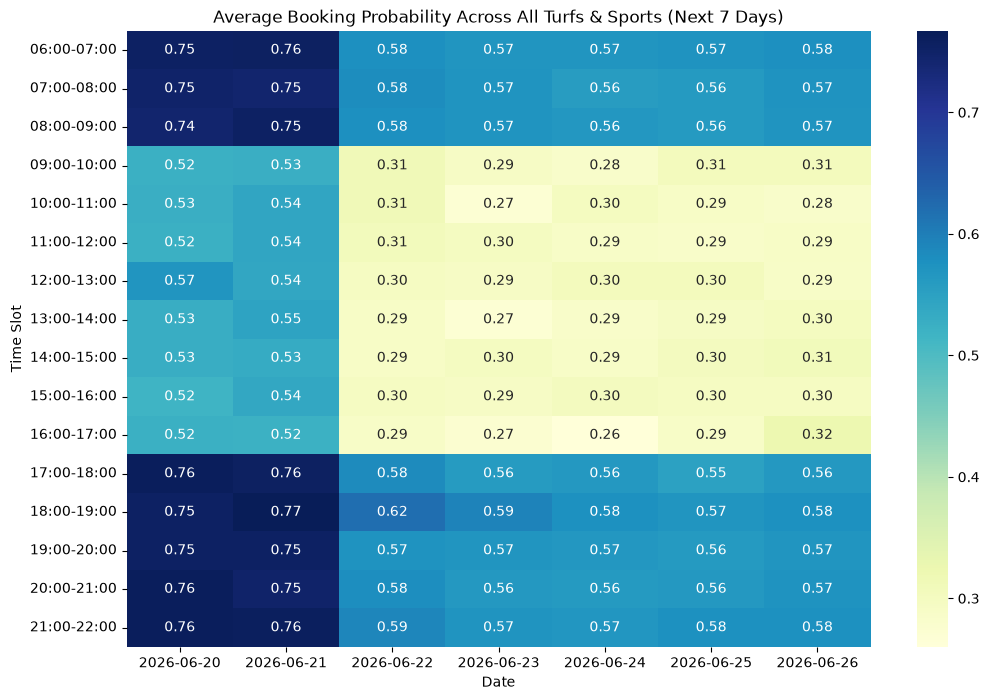

In [36]:
# ==========================================
# 5. VISUALIZATION (SYSTEM-WIDE HEATMAP)
# ==========================================
# We use pivot_table with aggfunc='mean' to average the probabilities 
# across all 50 turfs and 94 sports pitches for a high-level system view.

pivot_df = df_future[df_future['date'] <= (last_date + timedelta(days=7))].pivot_table(
    index='slot', 
    columns='date', 
    values='booking_prob',
    aggfunc='mean'  # <-- This prevents the crash!
)

# Format columns as string dates
pivot_df.columns = pivot_df.columns.strftime('%Y-%m-%d')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Average Booking Probability Across All Turfs & Sports (Next 7 Days)")
plt.xlabel("Date")
plt.ylabel("Time Slot")
plt.show()

# 6. Daily Volume Forecast (Prophet)
Using Prophet to predict the *total number of bookings* per day.

12:30:30 - cmdstanpy - INFO - Chain [1] start processing
12:30:31 - cmdstanpy - INFO - Chain [1] done processing


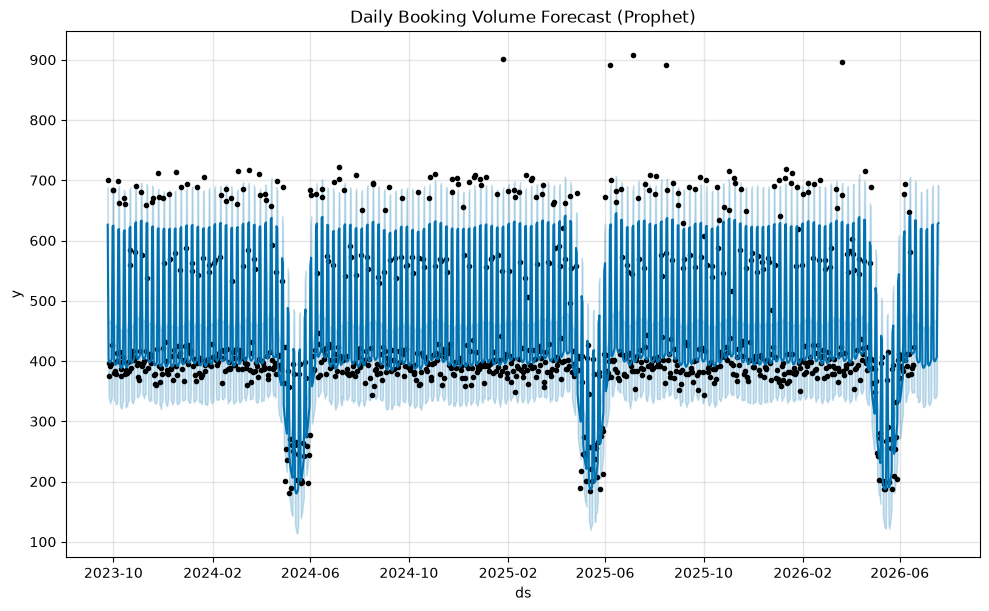

In [37]:
# Aggregate daily volume
daily_volume = df_train.groupby('date')['is_booked'].sum().reset_index()
daily_volume.columns = ['ds', 'y']

m = Prophet()
m.fit(daily_volume)

future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

# Plot
fig1 = m.plot(forecast)
plt.title("Daily Booking Volume Forecast (Prophet)")
plt.show()

In [38]:
# ========================================================
# 4. TUNED FORECASTING ENGINE (USING OPTIMIZED MODEL)
# ========================================================
from datetime import timedelta
import numpy as np
import pandas as pd

print("1. Generating Future Time Skeleton...")
last_date = df_train['date'].max()
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=30)

future_time_rows = []
for date in future_dates:
    for slot in ALL_SLOTS:
        future_time_rows.append({
            'date': date,
            'slot': slot,
            'day_of_week': date.weekday(),
            'is_weekend': 1 if date.weekday() >= 5 else 0,
            'hour': int(slot.split(':')[0]),
            'month': date.month
        })

df_future_time = pd.DataFrame(future_time_rows)

print("2. Cross-Joining with Pitches...")
df_future = pd.merge(df_future_time, melted_turfs, how='cross')

print("3. Building Master Future Feature Matrix...")
X_future = df_future[[
    'day_of_week', 'hour', 'month', 'is_weekend', 
    'base_hourly_charge', 'is_indoor', 'has_floodlights', 'has_parking'
]].copy()

# Add standard future assumptions
X_future['is_holiday'] = 0
X_future['weather_code'] = 1  
X_future['is_clear_weather'] = 1
X_future['is_adverse_weather'] = 0

# Encode Sports
sport_dummies = pd.get_dummies(df_future['sport_type'], prefix='sport')
X_future = pd.concat([X_future, sport_dummies], axis=1)

print("4. Applying Temporal Context & Peak Profiles...")
X_future['hour_sin'] = np.sin(2 * np.pi * X_future['hour'] / 24)
X_future['hour_cos'] = np.cos(2 * np.pi * X_future['hour'] / 24)
X_future['month_sin'] = np.sin(2 * np.pi * X_future['month'] / 12)
X_future['month_cos'] = np.cos(2 * np.pi * X_future['month'] / 12)
X_future['week_of_year'] = df_future['date'].dt.isocalendar().week
X_future['day_of_year'] = df_future['date'].dt.dayofyear
X_future['day_of_month'] = df_future['date'].dt.day
X_future['is_month_start'] = df_future['date'].dt.is_month_start.astype(int)
X_future['is_month_end'] = df_future['date'].dt.is_month_end.astype(int)
X_future['quarter'] = df_future['date'].dt.quarter

X_future['is_peak_hour'] = ((X_future['hour'] >= 6) & (X_future['hour'] <= 9)) | \
                           ((X_future['hour'] >= 16) & (X_future['hour'] <= 21))
X_future['is_morning_peak'] = (X_future['hour'] >= 6) & (X_future['hour'] <= 9)
X_future['is_evening_peak'] = (X_future['hour'] >= 16) & (X_future['hour'] <= 21)
X_future['is_off_peak'] = ((X_future['hour'] < 6) | (X_future['hour'] > 21)).astype(int)

def distance_to_peak(h):
    morning_peak, evening_peak = [6, 7, 8, 9], [18, 19, 20, 21]
    if h in morning_peak or h in evening_peak: return 0
    return min(min(abs(h - p) for p in morning_peak), min(abs(h - p) for p in evening_peak))

X_future['distance_to_peak'] = X_future['hour'].apply(distance_to_peak)
X_future['adjacent_to_peak'] = (((X_future['hour'] == 5) | (X_future['hour'] == 10) | 
     (X_future['hour'] == 17) | (X_future['hour'] == 22)).astype(int))

X_future['weekend_peak'] = X_future['is_weekend'] * X_future['is_peak_hour']
X_future['weekday_morning'] = (1 - X_future['is_weekend']) * X_future['is_morning_peak']
X_future['weekday_evening'] = (1 - X_future['is_weekend']) * X_future['is_evening_peak']
X_future['summer_season'] = ((X_future['month'] >= 6) & (X_future['month'] <= 8)).astype(int)
X_future['summer_peak'] = X_future['summer_season'] * X_future['is_peak_hour']
X_future['holiday_week'] = 0

def hour_cluster(h):
    if 6 <= h <= 9: return 1
    elif 10 <= h <= 15: return 2
    elif 16 <= h <= 21: return 3
    else: return 4
X_future['hour_cluster'] = X_future['hour'].apply(hour_cluster)

print("5. Mapping Historical Day/Hour Patterns to Future Grid...")
X_future = pd.merge(X_future, dow_hour_patterns, on=['day_of_week', 'hour'], how='left')
X_future['dow_hour_mean'] = X_future['dow_hour_mean'].fillna(0.5)
X_future['dow_hour_std'] = X_future['dow_hour_std'].fillna(0.0)

# !!! CRITICAL TUNING CHANGES LOGGED HERE !!!
print("6. Aligning Matrix to Tuned Model Features (Top 15 Columns)...")
# We force the future grid to look exactly like 'top_features_95' which we used to optimize the engine
X_future_tuned = X_future.reindex(columns=top_features_95, fill_value=0)

print("7. Predicting Future Probabilities via Optimized Engine...")
df_future['booking_prob'] = model_optimized.predict_proba(X_future_tuned)[:, 1]

print("✅ Tuned Future Forecast Generated Successfully!")
display(df_future[['date', 'slot', 'turf_id', 'sport_type', 'booking_prob']].head(10))

1. Generating Future Time Skeleton...
2. Cross-Joining with Pitches...
3. Building Master Future Feature Matrix...
4. Applying Temporal Context & Peak Profiles...
5. Mapping Historical Day/Hour Patterns to Future Grid...
6. Aligning Matrix to Tuned Model Features (Top 15 Columns)...
7. Predicting Future Probabilities via Optimized Engine...
✅ Tuned Future Forecast Generated Successfully!


,date,slot,turf_id,sport_type,booking_prob
0,2026-06-20,06:00-07:00,turf_001,Box Cricket,0.528361
1,2026-06-20,06:00-07:00,turf_002,Box Cricket,0.641238
2,2026-06-20,06:00-07:00,turf_003,Box Cricket,0.806252
3,2026-06-20,06:00-07:00,turf_004,Box Cricket,0.686339
4,2026-06-20,06:00-07:00,turf_005,Box Cricket,0.850908
5,2026-06-20,06:00-07:00,turf_007,Box Cricket,0.844425
6,2026-06-20,06:00-07:00,turf_008,Box Cricket,0.641450
7,2026-06-20,06:00-07:00,turf_009,Box Cricket,0.778193
8,2026-06-20,06:00-07:00,turf_010,Box Cricket,0.714840
9,2026-06-20,06:00-07:00,turf_011,Box Cricket,0.641450


Generating Pivot Table for Tuned Heatmap...


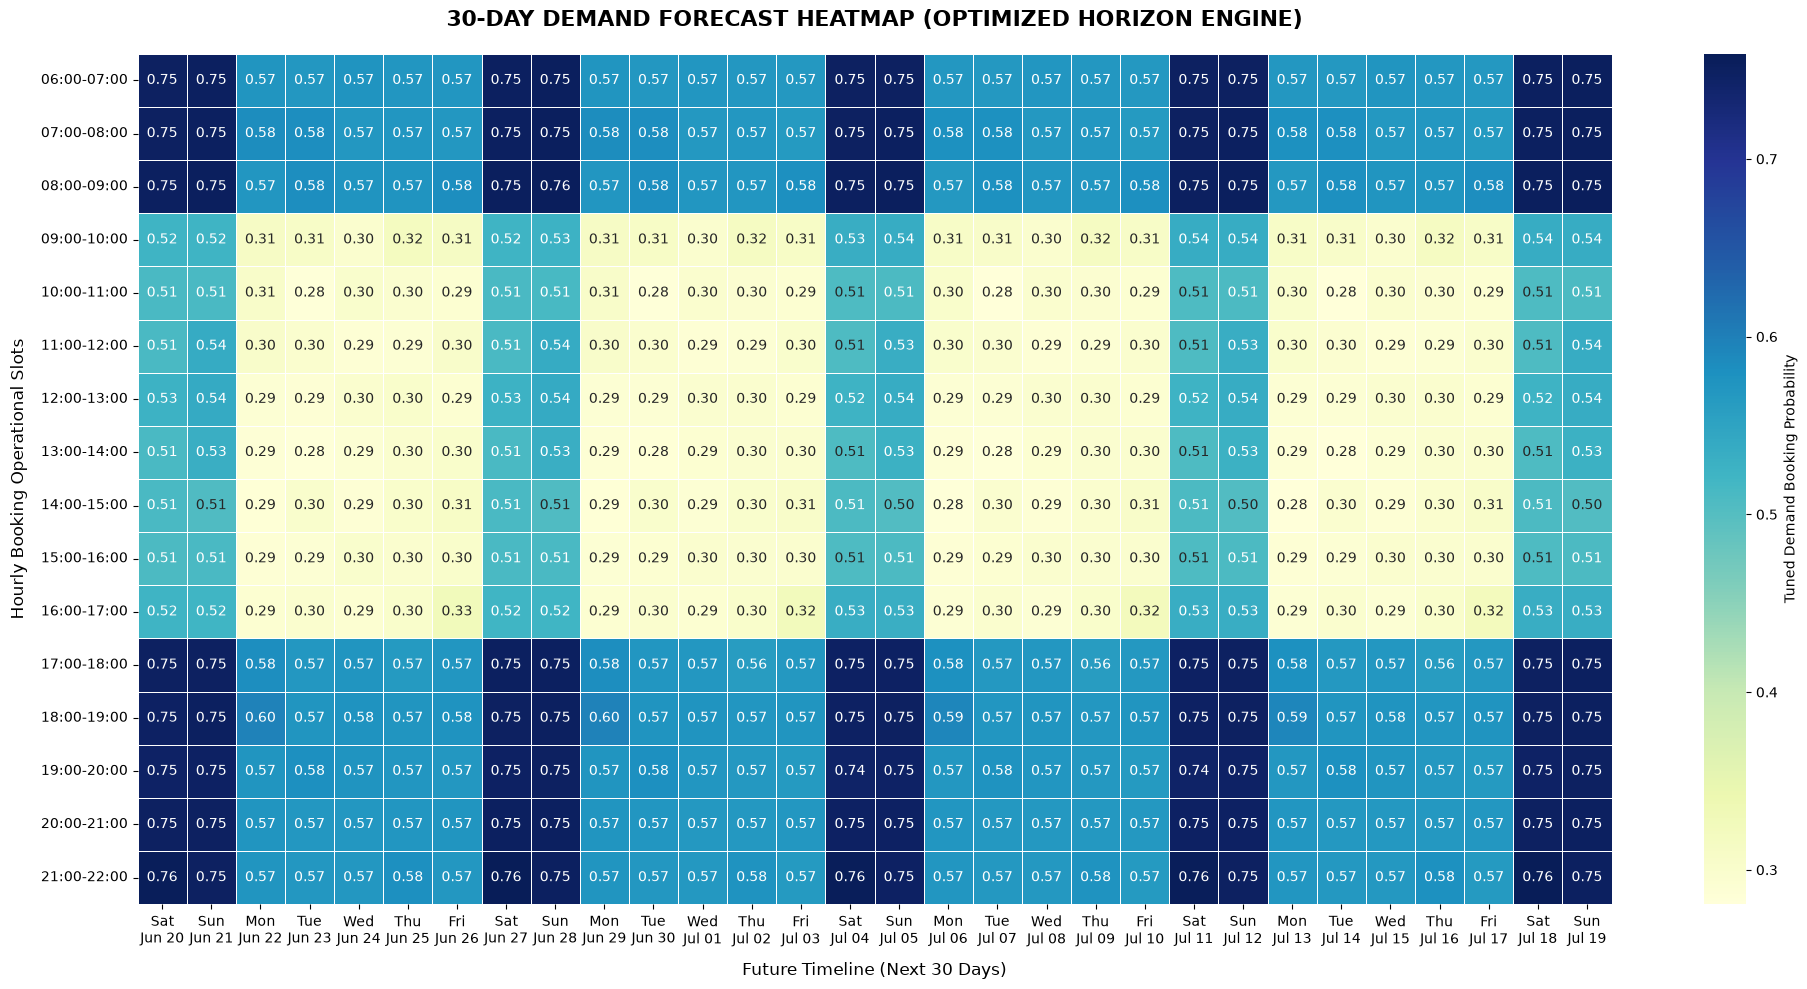

In [39]:
# ========================================================
# 5. HEATMAP VISUALIZATION (TUNED MODEL ENGINE)
# ========================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Pivot Table for Tuned Heatmap...")
# 1. Reshape the 30-day future dataframe into an Hour vs Date grid
# It automatically averages across all 94 pitches to show the macro trends
pivot_df_tuned = df_future.pivot_table(
    index='slot', 
    columns='date', 
    values='booking_prob', 
    aggfunc='mean'
)

# 2. Sort the hours correctly so morning is at the top, night at the bottom
pivot_df_tuned = pivot_df_tuned.reindex(ALL_SLOTS)

# 3. Format the date columns so the chart labels look clean (e.g., 'Mon Jun 15')
pivot_df_tuned.columns = [pd.to_datetime(col).strftime('%a\n%b %d') for col in pivot_df_tuned.columns]

# 4. Render the Matplotlib/Seaborn canvas
plt.figure(figsize=(20, 10))
sns.heatmap(
    pivot_df_tuned, 
    cmap='YlGnBu',     # Yellow to dark blue spectrum 
    annot=True,        # Show the raw probability decimals inside the squares
    fmt=".2f",         # Limit to 2 decimal places
    cbar_kws={'label': 'Tuned Demand Booking Probability'},
    linewidths=0.5
)

plt.title('30-DAY DEMAND FORECAST HEATMAP (OPTIMIZED HORIZON ENGINE)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Future Timeline (Next 30 Days)', fontsize=12, labelpad=10)
plt.ylabel('Hourly Booking Operational Slots', fontsize=12, labelpad=10)
plt.xticks(rotation=0) # Keep date texts perfectly horizontal and easy to read
plt.tight_layout()
plt.show()

Filtering 30-day prediction grid for turf_001 (Box Cricket)...


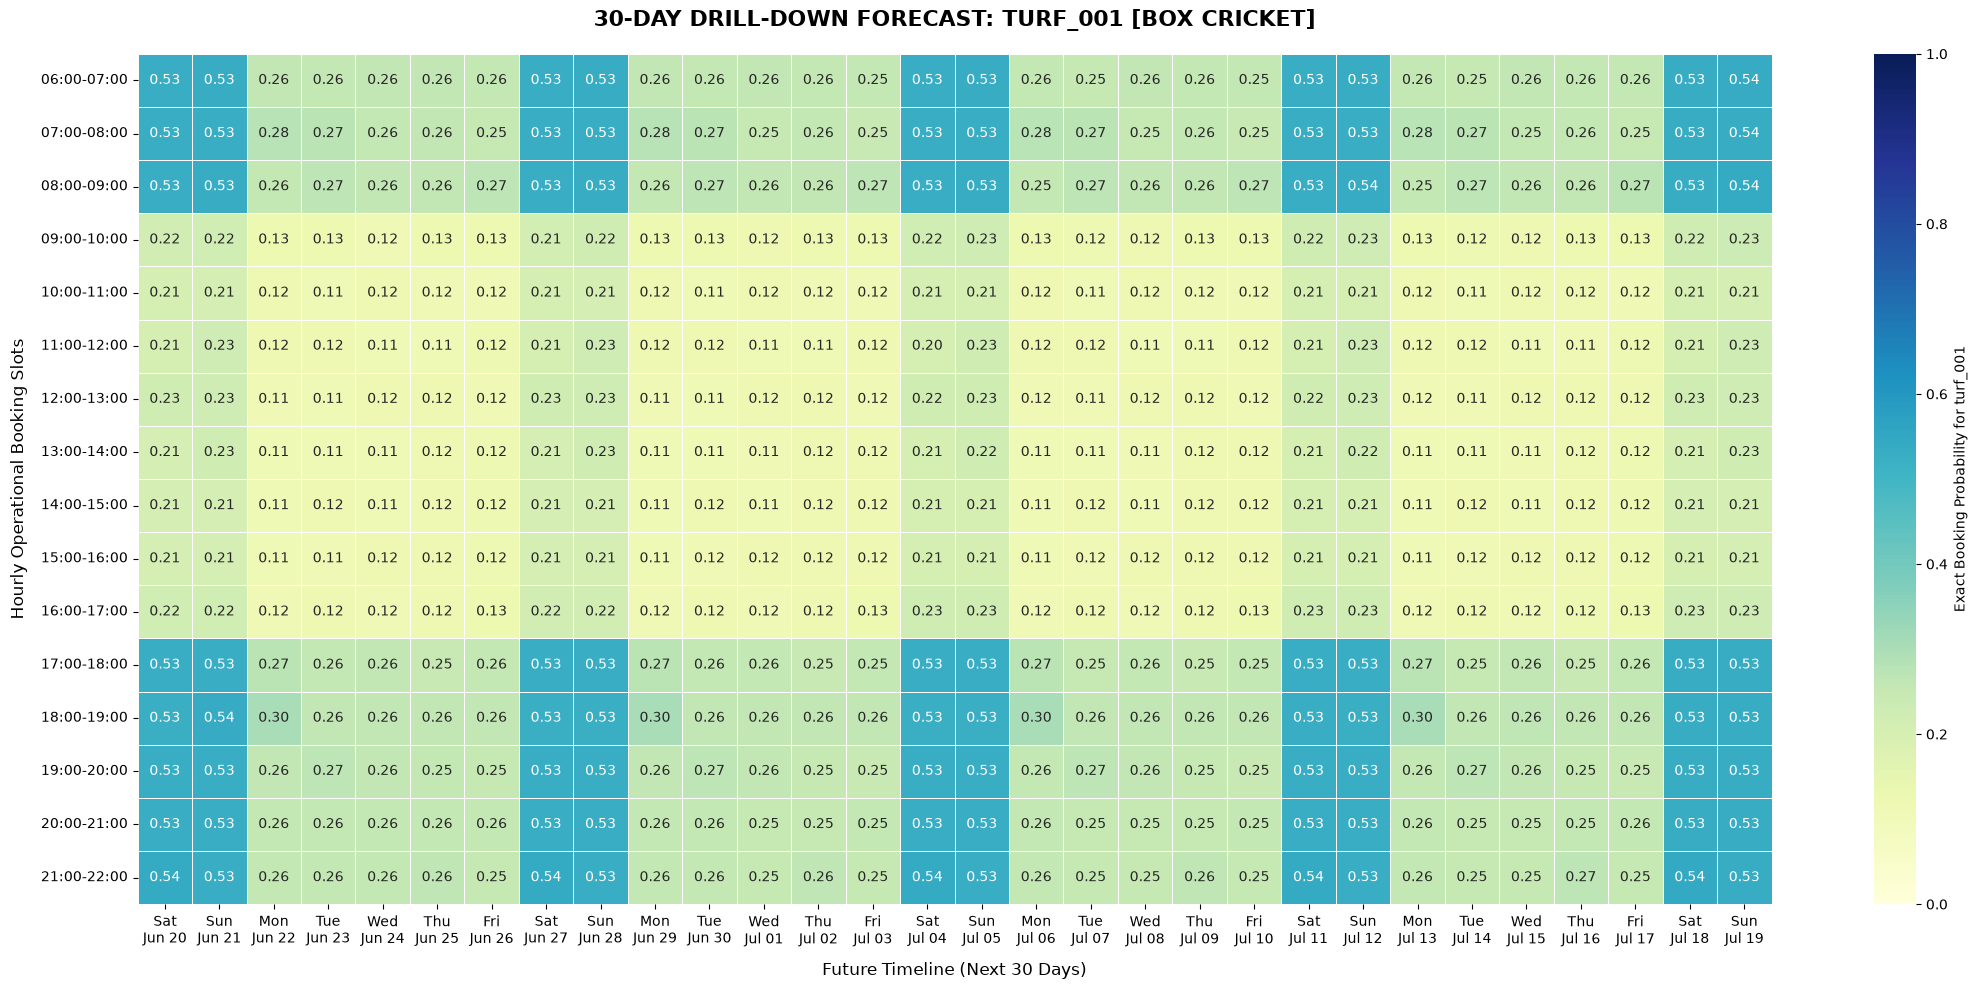

In [42]:
# ========================================================
# 6. SINGLE TURF / SPORT GRANULAR HEATMAP (30-DAY VIEW)
# ========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PICK YOUR TARGET FOR THE DRILL-DOWN
# Swap these strings out with any ID or sport from your database to check them
TARGET_TURF = 'turf_001'      
TARGET_SPORT = 'Box Cricket'

print(f"Filtering 30-day prediction grid for {TARGET_TURF} ({TARGET_SPORT})...")

# 2. Slice the master future dataframe for just this specific pitch
df_single_turf = df_future[
    (df_future['turf_id'] == TARGET_TURF) & 
    (df_future['sport_type'] == TARGET_SPORT)
].copy()

# 3. Create the pivot table (No averaging happening here since it's 1 unique slot per cell)
pivot_single = df_single_turf.pivot_table(
    index='slot', 
    columns='date', 
    values='booking_prob'
)

# 4. Sort chronological operational hours
pivot_single = pivot_single.reindex(ALL_SLOTS)

# 5. Format dates cleanly for the X-axis labels
pivot_single.columns = [pd.to_datetime(col).strftime('%a\n%b %d') for col in pivot_single.columns]

# 6. Render the granular visualization
plt.figure(figsize=(22, 10))
sns.heatmap(
    pivot_single, 
    cmap='YlGnBu',     # Yellow (Low) to Deep Navy Blue (High)
    annot=True,        # Show individual decimal probabilities
    fmt=".2f",         
    cbar_kws={'label': f'Exact Booking Probability for {TARGET_TURF}'},
    linewidths=0.5,
    vmin=0.0, vmax=1.0 # Set static scale boundary from 0% to 100%
)

plt.title(f'30-DAY DRILL-DOWN FORECAST: {TARGET_TURF.upper()} [{TARGET_SPORT.upper()}]', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Future Timeline (Next 30 Days)', fontsize=12, labelpad=10)
plt.ylabel('Hourly Operational Booking Slots', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
# Check the ground truth in your training data
weekend_evenings = df_train[
    (df_train['is_weekend'] == 1) & 
    (df_train['hour'].isin([17, 18, 19, 20, 21]))
]

print(f"Total weekend evening slots in training: {len(weekend_evenings)}")
print(f"Actual booked count (is_booked == 1): {weekend_evenings['is_booked'].sum()}")
print(f"Actual unbooked count (is_booked == 0): {(weekend_evenings['is_booked'] == 0).sum()}")
print(f"Historical success rate: {weekend_evenings['is_booked'].mean():.2%}")

Total weekend evening slots in training: 133950
Actual booked count (is_booked == 1): 68045
Actual unbooked count (is_booked == 0): 65905
Historical success rate: 50.80%


In [44]:
# 1. See what sports are associated with turf_002
available_sports = df_future[df_future['turf_id'] == 'turf_002']['sport_type'].unique()
print(f"✅ Sports available for turf_002: {available_sports}")

# 2. See the slot format (Are they '06:00', '06:00-07:00', or something else?)
available_slots = df_future[df_future['turf_id'] == 'turf_002']['slot'].unique()
print(f"✅ Slots available for turf_002: {available_slots[:5]}...") 

# 3. Check for Nulls in probabilities
null_count = df_future[df_future['turf_id'] == 'turf_002']['booking_prob'].isnull().sum()
print(f"✅ Number of empty probability slots for turf_002: {null_count}")

✅ Sports available for turf_002: <StringArray>
['Box Cricket']
Length: 1, dtype: str
✅ Slots available for turf_002: <StringArray>
['06:00-07:00', '07:00-08:00', '08:00-09:00', '09:00-10:00', '10:00-11:00']
Length: 5, dtype: str...
✅ Number of empty probability slots for turf_002: 0


In [45]:
# ========================================================
# 1. GENERATE SHORT-TERM FORECAST DATAFRAME
# ========================================================
# We use the LAST available data point as a "baseline" for the next 7 days
# because short-term momentum is driven by the most recent history.

# Create a slice of the next 7 days from your df_future
df_short_forecast = df_future[
    (df_future['date'] >= pd.Timestamp.now().normalize()) & 
    (df_future['date'] <= pd.Timestamp.now().normalize() + timedelta(days=7))
].copy()

# Add the momentum features by referencing the latest history from df_train
# (This ensures the model has the 'streak' and 'momentum' context it needs)
def prepare_momentum_data(df, df_train):
    # 1. Get the latest stats
    latest_stats = df_train.groupby(['turf_id', 'sport_type', 'slot']).agg({
        'booking_rate_7d': 'last',
        'streak_3d': 'last',
        'booking_rate_14d': 'last',
        'booking_momentum': 'last',
        'is_sunny': 'last',
        'is_rainy': 'last',
        'is_foggy': 'last',
        'is_cool': 'last',
        'temp': 'last',
        'is_extreme_heat': 'last',
        'month_sin': 'last',
        'month_cos': 'last'
    }).reset_index()

    # 2. Get the historical slot means (for baseline filling)
    slot_means = df_train.groupby(['turf_id', 'slot'])[['booking_rate_7d', 'streak_3d']].mean().reset_index()
    
    # 3. CORRECTED MERGE: Assign the result back to 'df'
    df = df.merge(latest_stats, on=['turf_id', 'sport_type', 'slot'], how='left')
    
    # 4. Fill missing values with slot_means
    for col in ['booking_rate_7d', 'streak_3d']:
        # Merge the mean and fill the NaN values
        df = df.merge(slot_means[['turf_id', 'slot', col]], on=['turf_id', 'slot'], how='left', suffixes=('', '_mean'))
        df[col] = df[col].fillna(df[f'{col}_mean'])
        df = df.drop(columns=[f'{col}_mean']) # Clean up
        
    # Final safety fill for remaining columns
    df = df.fillna(0)
        
    return df

# Usage
df_short_forecast = prepare_momentum_data(df_short_forecast, df_train)
features_to_scale = df_short_forecast[momentum_features]


df_short_forecast_scaled = scaler.transform(features_to_scale)


# Predict probabilities using the Short-Term Model
df_short_forecast['booking_prob'] = model_short_term.predict_proba(
    df_short_forecast[momentum_features]
)[:, 1]

print("✅ Short-Term Forecast (7-day) generated for all turfs.")

✅ Short-Term Forecast (7-day) generated for all turfs.


In [46]:
print(df_short_forecast['booking_prob'].describe())

count    10528.000000
mean         0.448239
std          0.224244
min          0.024392
25%          0.266244
50%          0.430267
75%          0.621637
max          0.969197
Name: booking_prob, dtype: float64


In [47]:
importances = pd.DataFrame({'feature': momentum_features, 'importance': model_short_term.feature_importances_})
print(importances.sort_values(by='importance', ascending=False))

               feature  importance
5     booking_momentum    0.289998
3   base_hourly_charge    0.225981
1                 hour    0.143011
0          day_of_week    0.125127
4            streak_3d    0.095260
10                temp    0.078323
7             is_rainy    0.011601
12           month_sin    0.009192
13           month_cos    0.007416
6             is_sunny    0.007317
8             is_foggy    0.006772
2           is_weekend    0.000000
9              is_cool    0.000000
11     is_extreme_heat    0.000000


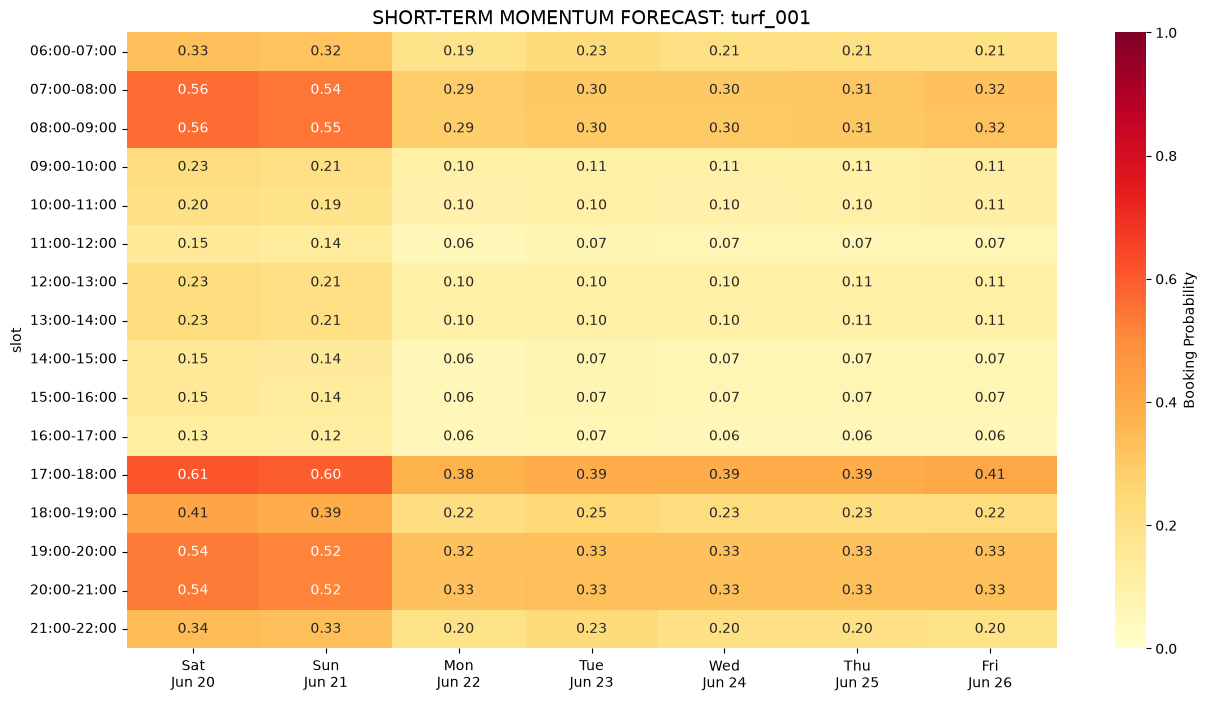

In [49]:
# ========================================================
# 2. VISUALIZE SHORT-TERM MODEL (7-DAY HEATMAP)
# ========================================================
from matplotlib.colors import PowerNorm
TARGET_TURF = 'turf_001'
TARGET_SPORT = 'Box Cricket'

df_viz = df_short_forecast[
    (df_short_forecast['turf_id'] == TARGET_TURF) & 
    (df_short_forecast['sport_type'] == TARGET_SPORT)
].pivot_table(index='slot', columns='date', values='booking_prob')

# Reindex and format
df_viz = df_viz.reindex(ALL_SLOTS)
df_viz.columns = [pd.to_datetime(col).strftime('%a\n%b %d') for col in df_viz.columns]

plt.figure(figsize=(15, 8))
sns.heatmap(df_viz, cmap='YlOrRd', annot=True, fmt=".2f", vmin=0, vmax=1.0, cbar_kws={'label': 'Booking Probability'})
plt.title(f'SHORT-TERM MOMENTUM FORECAST: {TARGET_TURF}', fontsize=14)
plt.show()

In [50]:
importances = pd.DataFrame({'feature': momentum_features, 'importance': model_short_term.feature_importances_})
print(importances.sort_values(by='importance', ascending=False))

               feature  importance
5     booking_momentum    0.289998
3   base_hourly_charge    0.225981
1                 hour    0.143011
0          day_of_week    0.125127
4            streak_3d    0.095260
10                temp    0.078323
7             is_rainy    0.011601
12           month_sin    0.009192
13           month_cos    0.007416
6             is_sunny    0.007317
8             is_foggy    0.006772
2           is_weekend    0.000000
9              is_cool    0.000000
11     is_extreme_heat    0.000000


In [51]:
# Check if a specific feature is spiking for the 1 PM slot
df_short_forecast.describe()

,date,day_of_week,is_weekend,hour,month,is_indoor,has_floodlights,has_parking,has_shower,has_cafeteria,...,booking_rate_14d,booking_momentum,is_sunny,is_rainy,is_foggy,is_cool,temp,is_extreme_heat,month_sin,month_cos
count,10528,10528.000000,10528.000000,10528.000000,10528.0,10528.000000,10528.000000,10528.000000,10528.000000,10528.000000,...,10528.000000,10528.000000,1.052800e+04,1.052800e+04,10528.0,10528.0,10528.0,10528.0,1.052800e+04,10528.0
mean,2026-06-23 00:00:00,3.000000,0.285714,13.500000,6.0,0.404255,0.500000,0.500000,0.521277,0.436170,...,0.311978,-0.007551,6.000000e-01,4.000000e-01,0.0,0.0,38.0,0.0,1.224647e-16,-1.0
min,2026-06-20 00:00:00,0.000000,0.000000,6.000000,6.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.357143,6.000000e-01,4.000000e-01,0.0,0.0,38.0,0.0,1.224647e-16,-1.0
25%,2026-06-21 00:00:00,1.000000,0.000000,9.750000,6.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.142857,-0.071429,6.000000e-01,4.000000e-01,0.0,0.0,38.0,0.0,1.224647e-16,-1.0
50%,2026-06-23 00:00:00,3.000000,0.000000,13.500000,6.0,0.000000,0.500000,0.500000,1.000000,0.000000,...,0.285714,0.000000,6.000000e-01,4.000000e-01,0.0,0.0,38.0,0.0,1.224647e-16,-1.0
75%,2026-06-25 00:00:00,5.000000,1.000000,17.250000,6.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.428571,0.071429,6.000000e-01,4.000000e-01,0.0,0.0,38.0,0.0,1.224647e-16,-1.0
max,2026-06-26 00:00:00,6.000000,1.000000,21.000000,6.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.928571,0.357143,6.000000e-01,4.000000e-01,0.0,0.0,38.0,0.0,1.224647e-16,-1.0
std,NaN,2.000095,0.451775,4.609991,0.0,0.490771,0.500024,0.500024,0.499571,0.495933,...,0.201280,0.115970,1.110276e-16,5.551379e-17,0.0,0.0,0.0,0.0,2.465307e-32,0.0
